# EDA 01 - AndinaLog IoT Gold

Analisis exploratorio obligatorio de la tabla Gold usada para predecir desviaciones
termicas durante los proximos 60 minutos (`desviacion_proximos_60min_flag`).

- Entrada: `datos/gold/andinalog_iot_modelado_gold.csv` (solo lectura).
- Unidad de observacion: **una lectura de telemetria**.
- Este notebook **no** reconstruye el objetivo, **no** imputa, **no** elimina registros
  y **no** entrena ningun modelo. Tampoco escribe archivos: el unico producto de esta
  etapa es el informe MD que se redacta despues de esta ejecucion.
- Filtros: siempre explicitos y documentados, nunca `dropna()` indiscriminado.

In [1]:
# --- Configuracion centralizada: rutas, nombres reales, constantes y parametros visuales.
import hashlib
import os
import platform
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid')


def detectar_raiz():
    relativa = Path('datos/gold/andinalog_iot_modelado_gold.csv')
    candidatas = []
    if os.getenv('ANDINALOG_ROOT'):
        candidatas.append(Path(os.environ['ANDINALOG_ROOT']))
    cwd = Path.cwd().resolve()
    candidatas.extend([cwd, *cwd.parents])
    visitadas = set()
    for candidata in candidatas:
        normalizada = candidata.resolve()
        if normalizada in visitadas:
            continue
        visitadas.add(normalizada)
        if (normalizada / relativa).exists():
            return normalizada
    raise FileNotFoundError('No se encontro datos/gold/andinalog_iot_modelado_gold.csv')


RAIZ = detectar_raiz()

CONFIG = {
    'rutas': {
        'gold': 'datos/gold/andinalog_iot_modelado_gold.csv',
        'informe': 'informes/eda/Informe_EDA_01_AndinaLog_IoT_Gold.md',
        'notebook': 'notebooks/eda/EDA_01_AndinaLog_IoT_Gold.ipynb',
    },
    # Nombres previstos por el prompt -> nombres reales en el CSV Gold.
    'mapeo_columnas': {
        'id_lectura': ('_fila_bronze', '_fila_bronze'),
        'entidad': ('viaje_id', 'viaje_id'),
        'orden': ('order_id', 'order_id'),
        'camion': ('camion_id', 'camion_id'),
        'producto': ('producto_id', 'producto_id'),
        'timestamp': ('timestamp', 'timestamp'),
        'temp_actual': ('temperatura_cabina_c', 'temperatura_cabina_c'),
        'humedad_actual': ('humedad_cabina_pct', 'humedad_cabina_pct'),
        'flag_actual': ('desviacion_termica_flag', 'desviacion_termica_flag'),
        'temp_anterior': ('temperatura_anterior', 'temperatura_anterior'),
        'var_30min': ('variacion_temperatura_30min', 'variacion_temperatura_30min'),
        'objetivo': ('desviacion_proximos_60min_flag', 'desviacion_proximos_60min_flag'),
        'ventana_evaluable': ('ventana_objetivo_evaluable', 'ventana_objetivo_evaluable'),
        'ts_temp_anterior': ('ts_temperatura_anterior', 'ts_temperatura_anterior'),
        'ts_base_var': ('ts_base_variacion', 'ts_base_variacion'),
        'motivo_temp_anterior': ('motivo_temperatura_anterior', 'motivo_temperatura_anterior'),
        'motivo_var_30min': ('motivo_variacion_30min', 'motivo_variacion_30min'),
        'calidad_estado': ('calidad_estado', 'calidad_estado'),
        'calidad_motivo': ('calidad_motivo', 'calidad_motivo'),
    },
    'clave_lectura': ['viaje_id', 'timestamp'],
    'patron_entidad': r'^VIA-\d{5}$',
    'predictores_minimos': [
        'temperatura_cabina_c',
        'humedad_cabina_pct',
        'desviacion_termica_flag',
        'temperatura_anterior',
        'variacion_temperatura_30min',
    ],
    'columnas_no_admisibles_como_entrada': [
        'desviacion_proximos_60min_flag',
        'ts_temperatura_anterior',
        'ts_base_variacion',
        'ventana_objetivo_evaluable',
        'motivo_temperatura_anterior',
        'motivo_variacion_30min',
        'objetivo_coincide_con_silver',
        'calidad_estado',
        'calidad_motivo',
    ],
    'horizonte_objetivo_min': 60,
    'ventana_variacion_min': 30,
    'centinela': -999.0,
    'humedad_rango_valido': (0.0, 100.0),
    'bandas_temperatura': [-np.inf, -10.0, 10.0, np.inf],
    'etiquetas_banda': ['congelado (<-10 C)', 'templado (-10 a 10 C)', 'calido (>10 C)'],
    'umbral_extremo_var': 5.0,
    'viajes_lineplot': 3,
    'min_lecturas_lineplot': 15,
    'bootstrap': {'n_resampleos': 2000, 'nivel': 0.95},
    'semilla': 20260925,
    'visual': {
        'figsize': (11, 5.5),
        'bins_hist': 40,
        'alpha_scatter': 0.35,
        's_scatter': 14,
        'paleta': {0: '#4C72B0', 1: '#C44E52'},
        'paleta_etiquetas': {'0 - sin desviacion futura': '#4C72B0',
                             '1 - con desviacion futura': '#C44E52'},
        'paleta_g4': {'0 (sin desviacion actual)': '#4C72B0',
                      '1 (con desviacion actual)': '#C44E52'},
    },
}

PATHS = {clave: RAIZ / relativa for clave, relativa in CONFIG['rutas'].items()}
COL = {clave: real for clave, (_, real) in CONFIG['mapeo_columnas'].items()}
PRED = CONFIG['predictores_minimos']
VIS = CONFIG['visual']
SEMILLA = CONFIG['semilla']
rng = np.random.default_rng(SEMILLA)

print('Raiz del proyecto:', RAIZ)
print('Ejecucion UTC:', datetime.now(timezone.utc).isoformat())
print('Python:', platform.python_version(), '| pandas:', pd.__version__,
      '| numpy:', np.__version__, '| seaborn:', sns.__version__,
      '| matplotlib:', matplotlib.__version__)
print('Semilla declarada:', SEMILLA)
print('Rutas de config:')
for clave, ruta in PATHS.items():
    print(f'  {clave:>8}: {ruta.relative_to(RAIZ).as_posix()}')

Raiz del proyecto: C:\Users\remrodri\Github\practicasNotebookColab\proyecto-integradorV2
Ejecucion UTC: 2026-09-25T19:28:38.739847+00:00
Python: 3.14.6 | pandas: 3.0.5 | numpy: 2.5.3 | seaborn: 0.13.2 | matplotlib: 3.11.2
Semilla declarada: 20260925
Rutas de config:
      gold: datos/gold/andinalog_iot_modelado_gold.csv
   informe: informes/eda/Informe_EDA_01_AndinaLog_IoT_Gold.md
  notebook: notebooks/eda/EDA_01_AndinaLog_IoT_Gold.ipynb


## 1. Carga y validacion

Se lee Gold en modo solo lectura. Se detiene la ejecucion con un mensaje claro si falta
cualquier columna obligatoria, y se documenta la correspondencia entre el nombre previsto
por el prompt y el nombre real del CSV.

In [2]:
# --- Carga sin modificar el archivo y validacion de columnas obligatorias.
HASH_GOLD_ENTRADA = hashlib.sha256(PATHS['gold'].read_bytes()).hexdigest()

gold = pd.read_csv(PATHS['gold'])

presentes = set(gold.columns)
faltantes = {clave: real for clave, real in COL.items() if real not in presentes}
if faltantes:
    raise ValueError(
        'Bloqueo: faltan columnas obligatorias en el Gold. '
        + '; '.join(f'{clave} -> {real}' for clave, real in sorted(faltantes.items()))
    )

print('Archivo Gold (solo lectura):', CONFIG['rutas']['gold'])
print('SHA-256 al inicio de la ejecucion:', HASH_GOLD_ENTRADA)
print('Forma Gold:', gold.shape)
print('Filas:', len(gold), '| Columnas:', gold.shape[1])
print()
print('Nombres de columnas encontrados:')
for indice, nombre in enumerate(gold.columns):
    print(f'  {indice:>2}: {nombre}')
print()
print('Correspondencia nombre previsto -> nombre real en Gold:')
for clave, (previsto, real) in CONFIG['mapeo_columnas'].items():
    marca = 'OK' if previsto == real else 'ADAPTADO'
    print(f'  {clave:>22}: {previsto} -> {real}  [{marca}]')
print()
print('Columnas configuradas ausentes:', len(faltantes))
print('Columnas del CSV fuera de la configuracion:',
      [c for c in gold.columns if c not in COL.values()])

Archivo Gold (solo lectura): datos/gold/andinalog_iot_modelado_gold.csv
SHA-256 al inicio de la ejecucion: f0194aae8dfe9073fd0e5bbf14cb72353a02863915e483ceec66027e81406479
Forma Gold: (28448, 20)
Filas: 28448 | Columnas: 20

Nombres de columnas encontrados:
   0: _fila_bronze
   1: timestamp
   2: viaje_id
   3: order_id
   4: camion_id
   5: producto_id
   6: temperatura_cabina_c
   7: humedad_cabina_pct
   8: desviacion_termica_flag
   9: temperatura_anterior
  10: ts_temperatura_anterior
  11: variacion_temperatura_30min
  12: ts_base_variacion
  13: motivo_temperatura_anterior
  14: motivo_variacion_30min
  15: desviacion_proximos_60min_flag
  16: ventana_objetivo_evaluable
  17: objetivo_coincide_con_silver
  18: calidad_estado
  19: calidad_motivo

Correspondencia nombre previsto -> nombre real en Gold:
              id_lectura: _fila_bronze -> _fila_bronze  [OK]
                 entidad: viaje_id -> viaje_id  [OK]
                   orden: order_id -> order_id  [OK]
            

In [3]:
# --- Confirmacion de la unidad de observacion: una fila = una lectura de telemetria.
entidad = COL['entidad']
orden = COL['orden']
clave = CONFIG['clave_lectura']

print('UNIDAD DE OBSERVACION')
print('  Una fila Gold representa una lectura de telemetria en el instante `timestamp`')
print('  dentro de un viaje. No hay agregacion, muestreo ni duplicacion intencional.')
print()
print('  Clave de lectura configurada:', clave)
print('  Filas duplicadas en la clave de lectura:', int(gold.duplicated(clave).sum()))
print('  Identificador de lectura unico:', bool(gold[COL['id_lectura']].is_unique))
print('  Entidades (viajes) distintas:', int(gold[entidad].nunique()))
print('  Ordenes distintas:', int(gold[orden].nunique()))
print('  Camiones distintos:', int(gold[COL['camion']].nunique()))
print('  Productos distintos:', int(gold[COL['producto']].nunique()))
print('  Ordenes por viaje (maximo):', int(gold.groupby(entidad)[orden].nunique().max()))
print('  Camiones por viaje (maximo):', int(gold.groupby(entidad)[COL['camion']].nunique().max()))
print('  Viajes fuera del patron', CONFIG['patron_entidad'] + ':',
      int((~gold[entidad].str.fullmatch(CONFIG['patron_entidad'])).sum()))
print()
print('  Lecturas por viaje (describe):')
print(gold.groupby(entidad).size().describe().to_string())

UNIDAD DE OBSERVACION
  Una fila Gold representa una lectura de telemetria en el instante `timestamp`
  dentro de un viaje. No hay agregacion, muestreo ni duplicacion intencional.

  Clave de lectura configurada: ['viaje_id', 'timestamp']
  Filas duplicadas en la clave de lectura: 0
  Identificador de lectura unico: True
  Entidades (viajes) distintas: 1200
  Ordenes distintas: 1200
  Camiones distintos: 30
  Productos distintos: 60
  Ordenes por viaje (maximo): 1
  Camiones por viaje (maximo): 1
  Viajes fuera del patron ^VIA-\d{5}$: 0

  Lecturas por viaje (describe):
count    1200.000000
mean       23.706667
std         0.540863
min        21.000000
25%        23.000000
50%        24.000000
75%        24.000000
max        24.000000


## 2. Controles estructurales previos

Forma, tipos, faltantes, duplicados, ventana temporal, frecuencias categoricas y
estadisticas descriptivas de las variables numericas.

In [4]:
# --- Numero de filas y columnas, con rol declarado por columna.
roles = {
    COL['id_lectura']: 'identificador_lectura',
    COL['timestamp']: 'marca_tiempo_prediccion',
    entidad: 'identificador_entidad',
    orden: 'identificador_contexto',
    COL['camion']: 'identificador_contexto',
    COL['producto']: 'identificador_contexto',
    COL['temp_actual']: 'predictor',
    COL['humedad_actual']: 'predictor',
    COL['flag_actual']: 'predictor',
    COL['temp_anterior']: 'predictor',
    COL['var_30min']: 'predictor',
    COL['ts_temp_anterior']: 'control_ventana',
    COL['ts_base_var']: 'control_ventana',
    COL['motivo_temp_anterior']: 'auditoria',
    COL['motivo_var_30min']: 'auditoria',
    COL['objetivo']: 'objetivo',
    COL['ventana_evaluable']: 'control_cobertura',
    'objetivo_coincide_con_silver': 'auditoria',
    COL['calidad_estado']: 'auditoria',
    COL['calidad_motivo']: 'auditoria',
}
inventario = pd.DataFrame({
    'columna': gold.columns,
    'rol': [roles.get(c, 'sin_rol') for c in gold.columns],
    'dtype': [str(t) for t in gold.dtypes],
    'nulos': [int(gold[c].isna().sum()) for c in gold.columns],
    'no_nulos': [int(gold[c].notna().sum()) for c in gold.columns],
    'n_unicos': [int(gold[c].nunique(dropna=True)) for c in gold.columns],
    'ejemplo': [str(gold[c].dropna().iloc[0]) if gold[c].notna().any() else '' for c in gold.columns],
})

print('1) NUMERO DE FILAS Y COLUMNAS')
print('   Filas:', len(gold), '| Columnas:', gold.shape[1])
print()
display(inventario)
print('   Columnas con rol sin definir:', int((inventario['rol'] == 'sin_rol').sum()))

1) NUMERO DE FILAS Y COLUMNAS
   Filas: 28448 | Columnas: 20



,columna,rol,dtype,nulos,no_nulos,n_unicos,ejemplo
0,_fila_bronze,identificador_lectura,int64,0,28448,28448,2
1,timestamp,marca_tiempo_prediccion,str,0,28448,20938,2026-08-11 18:11:00+00:00
2,viaje_id,identificador_entidad,str,0,28448,1200,VIA-00001
3,order_id,identificador_contexto,str,0,28448,1200,ORD-2026-05710
4,camion_id,identificador_contexto,str,0,28448,30,CAM-20
5,producto_id,identificador_contexto,str,0,28448,60,PROD-045
6,temperatura_cabina_c,predictor,float64,0,28448,2386,2.19
7,humedad_cabina_pct,predictor,float64,98,28350,715,72.6
8,desviacion_termica_flag,predictor,int64,0,28448,2,0
9,temperatura_anterior,predictor,float64,1200,27248,2376,2.19


   Columnas con rol sin definir: 0


In [5]:
# --- Tipos de datos declarados.
print('5) TIPOS DE DATOS')
print('   Tipos presentes:', sorted({str(t) for t in gold.dtypes}))
print()
display(pd.DataFrame({'columna': gold.columns, 'dtype': [str(t) for t in gold.dtypes]})
        .groupby('dtype')['columna'].agg(['size', lambda s: ', '.join(s)]).reset_index()
        .rename(columns={'size': 'n_columnas', 'lambda1': 'columnas'}))
print('   Variables booleanas:', [c for c in gold.columns if gold[c].dtype == bool])
print('   Variables numericas:', list(gold.select_dtypes(include=[np.number]).columns))
print('   Variables de texto:', list(gold.select_dtypes(exclude=[np.number]).columns))

5) TIPOS DE DATOS
   Tipos presentes: ['bool', 'float64', 'int64', 'str']



,dtype,n_columnas,<lambda_0>
0,bool,2,"ventana_objetivo_evaluable, objetivo_coincide_con_silver"
1,float64,5,"temperatura_cabina_c, humedad_cabina_pct, temperatura_an..."
2,int64,2,"_fila_bronze, desviacion_termica_flag"
3,str,11,"timestamp, viaje_id, order_id, camion_id, producto_id, t..."


   Variables booleanas: ['ventana_objetivo_evaluable', 'objetivo_coincide_con_silver']
   Variables numericas: ['_fila_bronze', 'temperatura_cabina_c', 'humedad_cabina_pct', 'desviacion_termica_flag', 'temperatura_anterior', 'variacion_temperatura_30min', 'desviacion_proximos_60min_flag']
   Variables de texto: ['timestamp', 'viaje_id', 'order_id', 'camion_id', 'producto_id', 'ts_temperatura_anterior', 'ts_base_variacion', 'motivo_temperatura_anterior', 'motivo_variacion_30min', 'ventana_objetivo_evaluable', 'objetivo_coincide_con_silver', 'calidad_estado', 'calidad_motivo']


In [6]:
# --- Valores faltantes por columna y porcentaje de faltantes.
nulos = pd.DataFrame({
    'nulos': gold.isna().sum(),
    'no_nulos': gold.notna().sum(),
})
nulos['pct_faltantes'] = (nulos['nulos'] / len(gold) * 100).round(4)
nulos = nulos[nulos['nulos'] > 0].sort_values('nulos', ascending=False)

print('4) VALORES FALTANTES POR COLUMNA')
if len(nulos):
    display(nulos)
else:
    print('   Ninguna columna con faltantes.')
print('   Columnas con al menos un faltante:', len(nulos))
print('   Total de celdas faltantes:', int(gold.isna().sum().sum()))
print('   Faltantes en columnas de identificadores:',
      int(gold[[COL['id_lectura'], entidad, orden, COL['timestamp']]].isna().sum().sum()))

4) VALORES FALTANTES POR COLUMNA


,nulos,no_nulos,pct_faltantes
motivo_temperatura_anterior,27248,1200,95.7818
motivo_variacion_30min,26933,1515,94.6745
desviacion_proximos_60min_flag,2671,25777,9.3891
variacion_temperatura_30min,1515,26933,5.3255
ts_base_variacion,1515,26933,5.3255
temperatura_anterior,1200,27248,4.2182
ts_temperatura_anterior,1200,27248,4.2182
humedad_cabina_pct,98,28350,0.3445


   Columnas con al menos un faltante: 8
   Total de celdas faltantes: 62380
   Faltantes en columnas de identificadores: 0


In [7]:
# --- Duplicados: exactos, en clave de lectura y en identificador de lectura.
print('3) DUPLICADOS')
print('   Duplicados exactos (fila completa):', int(gold.duplicated().sum()))
print('   Duplicados en la clave de lectura', clave, ':', int(gold.duplicated(clave).sum()))
print('   Duplicados en', COL['id_lectura'], ':', int(gold[COL['id_lectura']].duplicated().sum()))
print('   Lecturas repetidas en el mismo viaje y timestamp:',
      int(gold.groupby(clave).size().gt(1).sum()))
print('   Ninguna fila se elimina: los duplicados se reportan, no se corrigen en el EDA.')

3) DUPLICADOS
   Duplicados exactos (fila completa): 0
   Duplicados en la clave de lectura ['viaje_id', 'timestamp'] : 0


   Duplicados en

 _fila_bronze : 0
   Lecturas repetidas en el mismo viaje y timestamp: 0
   Ninguna fila se elimina: los duplicados se reportan, no se corrigen en el EDA.


In [8]:
# --- Ventana temporal, conteos de entidades y frecuencias categoricas y de banderas.
ts = pd.to_datetime(gold[COL['timestamp']], format='ISO8601', utc=True)

print('7) TIMESTAMPS Y ENTIDADES')
print('   Timestamp minimo (UTC):', ts.min())
print('   Timestamp maximo (UTC):', ts.max())
print('   Timestamps no parseables:', int(ts.isna().sum()))
print('   Sufijos de zona horaria en el texto original:',
      sorted({str(v)[-6:] for v in gold[COL['timestamp']].head(1000)}))
print('   Viajes distintos:', int(gold[entidad].nunique()))
print('   Ordenes distintas:', int(gold[orden].nunique()))
print('   Camiones distintos:', int(gold[COL['camion']].nunique()))
print()
print('   Filas por viaje (resumen):')
print(gold.groupby(entidad).size().describe().to_string())
print()
print('   Filas por viaje (frecuencia de tamaÃ±os):')
print(gold.groupby(entidad).size().value_counts().sort_index().to_string())
print()
print('   Ventanas de tiempo observadas por viaje (intervalos internos, minutos):')
ordenado = pd.DataFrame({'entidad': gold[entidad].to_numpy(), 'ts': ts.to_numpy()}) \
    .sort_values(['entidad', 'ts'], kind='stable')
gaps = ordenado.groupby('entidad')['ts'].diff().dt.total_seconds().div(60).dropna()
print(gaps.value_counts().sort_index().to_string())
print('   Intervalo mediano:', float(gaps.median()), 'minutos')

7) TIMESTAMPS Y ENTIDADES
   Timestamp minimo (UTC): 2026-08-01 04:10:00+00:00
   Timestamp maximo (UTC): 2026-08-31 15:11:00+00:00
   Timestamps no parseables: 0
   Sufijos de zona horaria en el texto original: ['+00:00']
   Viajes distintos: 1200
   Ordenes distintas: 1200
   Camiones distintos: 30

   Filas por viaje (resumen):
count    1200.000000
mean       23.706667
std         0.540863
min        21.000000
25%        23.000000
50%        24.000000
75%        24.000000
max        24.000000

   Filas por viaje (frecuencia de tamaÃ±os):
21      7
22     30
23    271
24    892

   Ventanas de tiempo observadas por viaje (intervalos internos, minutos):


ts
30.0    26933
60.0      313
90.0        2
   Intervalo mediano: 30.0 minutos


In [9]:
# --- Estadisticas descriptivas de variables numericas (sin identificadores numericos).
numericas = [c for c in gold.select_dtypes(include=[np.number]).columns
             if c not in {COL['id_lectura']}]
print('6) ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS')
print('   Numericas analizadas:', numericas)
print('   Identificadores excluidos del resumen numerico:', [COL['id_lectura']])
print()
display(gold[numericas].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
        .round(4))

6) ESTADISTICAS DESCRIPTIVAS DE VARIABLES NUMERICAS
   Numericas analizadas: ['temperatura_cabina_c', 'humedad_cabina_pct', 'desviacion_termica_flag', 'temperatura_anterior', 'variacion_temperatura_30min', 'desviacion_proximos_60min_flag']
   Identificadores excluidos del resumen numerico: ['_fila_bronze']



,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
temperatura_cabina_c,28448.0,8.3488,14.0397,-21.63,-19.23,-18.43,3.44,15.5706,20.04,22.4265,24.1800,29.6900
humedad_cabina_pct,28350.0,61.4729,15.4583,20.70,33.80,39.20,48.00,60.3000,75.10,85.3000,91.2000,100.0000
desviacion_termica_flag,28448.0,0.0330,0.1788,0.00,0.00,0.00,0.00,0.0000,0.00,0.0000,1.0000,1.0000
temperatura_anterior,27248.0,8.3571,14.0370,-21.63,-19.23,-18.42,3.44,15.6200,20.04,22.4300,24.2253,29.6900
variacion_temperatura_30min,26933.0,-0.0034,2.1017,-11.28,-5.75,-3.49,-1.14,-0.0200,1.13,3.4700,5.7068,12.7811
desviacion_proximos_60min_flag,25777.0,0.0504,0.2188,0.00,0.00,0.00,0.00,0.0000,0.00,1.0000,1.0000,1.0000


In [10]:
# --- Frecuencias de variables categoricas y de banderas.
print('8) FRECUENCIAS DE CATEGORICAS Y BANDERAS')
for columna in [COL['ventana_evaluable'], COL['flag_actual'], COL['calidad_estado'],
                COL['calidad_motivo'], COL['motivo_temp_anterior'], COL['motivo_var_30min'],
                'objetivo_coincide_con_silver']:
    print(f'   {columna}:')
    conteo = gold[columna].value_counts(dropna=False)
    for valor, cantidad in conteo.items():
        etiqueta = '<nulo>' if pd.isna(valor) else valor
        print(f'      {etiqueta}: {cantidad} ({cantidad / len(gold) * 100:.2f}%)')
    print()
print('   Objetivo (toda la poblacion, incluidos nulos):')
conteo_objetivo = gold[COL['objetivo']].value_counts(dropna=False)
for valor, cantidad in conteo_objetivo.items():
    etiqueta = '<nulo>' if pd.isna(valor) else str(int(valor))
    print(f'      {etiqueta}: {cantidad} ({cantidad / len(gold) * 100:.2f}%)')

8) FRECUENCIAS DE CATEGORICAS Y BANDERAS
   ventana_objetivo_evaluable:
      True: 25777 (90.61%)
      False: 2671 (9.39%)

   desviacion_termica_flag:
      0: 27508 (96.70%)
      1: 940 (3.30%)

   calidad_estado:
      objetivo_evaluable: 25777 (90.61%)
      objetivo_no_evaluable: 2671 (9.39%)

   calidad_motivo:
      ventana_60min_observada_dentro_de_la_entidad: 25777 (90.61%)
      sin_cobertura_futura_hasta_60min_en_la_entidad: 2671 (9.39%)

   motivo_temperatura_anterior:
      <nulo>: 27248 (95.78%)
      primera_lectura_del_viaje: 1200 (4.22%)

   motivo_variacion_30min:
      <nulo>: 26933 (94.67%)
      primera_lectura_del_viaje: 1200 (4.22%)
      sin_lectura_en_[t-45,t-30]_minutos: 315 (1.11%)

   objetivo_coincide_con_silver:
      True: 25774 (90.60%)
      False: 2674 (9.40%)

   Objetivo (toda la poblacion, incluidos nulos):
      0: 24477 (86.04%)
      <nulo>: 2671 (9.39%)
      1: 1300 (4.57%)


## 3. Control de granularidad

Se verifica que Gold no multiplico registros y se contrasta el conteo de filas con el
informe aprobado de construccion de Gold.

In [11]:
# --- Evidencia de que Gold no multiplico registros, con contraste contra el informe Gold.
informe_gold = RAIZ / 'informes/silver_gold/Informe_S2G_01_IoT_Gold.md'
texto_informe = informe_gold.read_text(encoding='utf-8') if informe_gold.exists() else None
if texto_informe is None:
    print('  Informe Gold no disponible en', informe_gold.relative_to(RAIZ).as_posix())
    print('  Control de conciliacion omitido; se continua con la verificacion directa sobre el CSV.')

def _buscar(patron):
    if texto_informe is None:
        return None
    encontrado = re.search(patron, texto_informe)
    return int(encontrado.group(1)) if encontrado else None


filas_silver_informe = _buscar(r'Filas Silver:\s*(\d+)')
filas_gold_informe = _buscar(r'Filas Gold:\s*(\d+)')
viajes_informe = _buscar(r'Viajes:\s*(\d+)')
evaluables_informe = _buscar(r'Ventanas evaluables:\s*(\d+)')
no_evaluables_informe = _buscar(r'Ventanas no evaluables:\s*(\d+)')

tamano_por_viaje = gold.groupby(entidad).size()
lecturas_por_orden = gold.groupby(orden).size()

print('CONTROL DE GRANULARIDAD')
print('  Filas leidas en esta ejecucion:', len(gold))
print('  Filas Silver declaradas en el informe Gold:', filas_silver_informe)
print('  Filas Gold declaradas en el informe Gold:', filas_gold_informe)
if filas_silver_informe is not None:
    print('  Diferencia Gold - Silver:', len(gold) - filas_silver_informe)
if filas_gold_informe is not None:
    print('  Diferencia Gold leido - Gold declarado:', len(gold) - filas_gold_informe)
print()
print('  Unicidad de la clave de lectura:', bool(not gold.duplicated(clave).any()))
print('  Viajes distintos leidos:', int(gold[entidad].nunique()),
      '| declarados en el informe:', viajes_informe)
print('  Lecturas por viaje: minimo', int(tamano_por_viaje.min()),
      '| maximo', int(tamano_por_viaje.max()),
      '| mediana', float(tamano_por_viaje.median()))
print('  Lecturas por orden: minimo', int(lecturas_por_orden.min()),
      '| maximo', int(lecturas_por_orden.max()))
print('  Ningun viaje supera 24 lecturas:',
      bool(tamano_por_viaje.max() <= 24),
      '| maximo observado:', int(tamano_por_viaje.max()))
print('  Cobertura del objetivo leida: evaluables', int(gold[COL['ventana_evaluable']].sum()),
      '| no evaluables', int((~gold[COL['ventana_evaluable']]).sum()),
      '| declarados en el informe:', evaluables_informe, '/', no_evaluables_informe)
print()
print('  Conclusion de granularidad: una fila Gold por lectura Silver, sin join, sin agregado')
print('  y sin fan-out. Las diferencias, si las hubiera, se muestran arriba sin ocultarlas.')

CONTROL DE GRANULARIDAD
  Filas leidas en esta ejecucion: 28448
  Filas Silver declaradas en el informe Gold: 28448
  Filas Gold declaradas en el informe Gold: 28448
  Diferencia Gold - Silver: 0
  Diferencia Gold leido - Gold declarado: 0

  Unicidad de la clave de lectura: True
  Viajes distintos leidos: 1200 | declarados en el informe: 1200
  Lecturas por viaje: minimo 21 | maximo 24 | mediana 24.0
  Lecturas por orden: minimo 21 | maximo 24
  Ningun viaje supera 24 lecturas: True | maximo observado: 24
  Cobertura del objetivo leida: evaluables 25777 | no evaluables 2671 | declarados en el informe: 25777 / 2671

  Conclusion de granularidad: una fila Gold por lectura Silver, sin join, sin agregado
  y sin fan-out. Las diferencias, si las hubiera, se muestran arriba sin ocultarlas.


In [12]:
# --- Controles contra fuga temporal: los antecedentes nunca son posteriores al instante t.
ts_temp_ant = pd.to_datetime(gold[COL['ts_temp_anterior']], format='ISO8601', utc=True)
ts_base_var = pd.to_datetime(gold[COL['ts_base_var']], format='ISO8601', utc=True)

violan_temp = int((ts_temp_ant > ts).fillna(False).sum())
violan_var = int((ts_base_var > ts).fillna(False).sum())
sin_ts_temp = int((gold[COL['temp_anterior']].notna() & ts_temp_ant.isna()).sum())
sin_ts_var = int((gold[COL['var_30min']].notna() & ts_base_var.isna()).sum())

print('CONTROLES CONTRA FUGA TEMPORAL (verificacion, no construccion del objetivo)')
print('  ts_temperatura_anterior > timestamp:', violan_temp)
print('  ts_base_variacion > timestamp:', violan_var)
print('  Temperatura anterior presente sin marca de tiempo:', sin_ts_temp)
print('  Variacion presente sin marca de tiempo:', sin_ts_var)
print('  Predictores minimos disjuntos de las columnas no admisibles:',
      sorted(set(PRED) & set(CONFIG['columnas_no_admisibles_como_entrada'])) == [])
print('  El objetivo no se recalcula en este notebook: solo se lee y se cuenta.')

CONTROLES CONTRA FUGA TEMPORAL (verificacion, no construccion del objetivo)
  ts_temperatura_anterior > timestamp: 0
  ts_base_variacion > timestamp: 0
  Temperatura anterior presente sin marca de tiempo: 0
  Variacion presente sin marca de tiempo: 0
  Predictores minimos disjuntos de las columnas no admisibles: True
  El objetivo no se recalcula en este notebook: solo se lee y se cuenta.


## 4. Clasificacion de faltantes

Se separan los faltantes **esperados**, que tienen causa declarada en Gold, de los
**inesperados**. Ninguno se imputa y ninguno se elimina.

In [13]:
# --- Clasificacion de faltantes: esperados por ventana temporal o heredados vs inesperados.
temp_ant = COL['temp_anterior']
var_30 = COL['var_30min']
mot_temp = COL['motivo_temp_anterior']
mot_var = COL['motivo_var_30min']
objetivo = COL['objetivo']
evaluable = COL['ventana_evaluable']

n_total = len(gold)
primera_lectura = gold[mot_temp].eq('primera_lectura_del_viaje') | gold[mot_var].eq('primera_lectura_del_viaje')
sin_historia = gold[mot_var].eq('sin_lectura_en_[t-45,t-30]_minutos')
ventana_no_evaluable = ~gold[evaluable]

clasificacion = pd.DataFrame([
    {'columna': temp_ant, 'tipo': 'esperado', 'motivo': 'primera lectura del viaje, sin lectura previa',
     'filas': int(gold[temp_ant].isna().sum())},
    {'columna': var_30, 'tipo': 'esperado', 'motivo': 'primera lectura del viaje, sin lectura previa',
     'filas': int((gold[var_30].isna() & primera_lectura).sum())},
    {'columna': var_30, 'tipo': 'esperado',
     'motivo': 'sin lectura en [t-45, t-30] min (intervalo previo de 60 o 90 min)',
     'filas': int((gold[var_30].isna() & sin_historia).sum())},
    {'columna': COL['humedad_actual'], 'tipo': 'esperado (heredado de Silver)',
     'motivo': 'vacio de origen, conservado sin imputar', 'filas': int(gold[COL['humedad_actual']].isna().sum())},
    {'columna': objetivo, 'tipo': 'esperado',
     'motivo': 'ventana futura de 60 min no evaluable dentro del viaje',
     'filas': int(gold[objetivo].isna().sum())},
    {'columna': COL['ts_temp_anterior'], 'tipo': 'esperado (refleja el derivado)',
     'motivo': 'sin temperatura anterior no hay instante de referencia',
     'filas': int(gold[COL['ts_temp_anterior']].isna().sum())},
    {'columna': COL['ts_base_var'], 'tipo': 'esperado (refleja el derivado)',
     'motivo': 'sin variacion no hay instante base', 'filas': int(gold[COL['ts_base_var']].isna().sum())},
    {'columna': mot_temp, 'tipo': 'esperado (nulo cuando el derivado existe)',
     'motivo': 'el motivo solo existe cuando el derivado falta',
     'filas': int(gold[mot_temp].isna().sum())},
    {'columna': mot_var, 'tipo': 'esperado (nulo cuando el derivado existe)',
     'motivo': 'el motivo solo existe cuando el derivado falta',
     'filas': int(gold[mot_var].isna().sum())},
])

esperados_por_columna = (clasificacion[clasificacion['tipo'].str.startswith('esperado')]
                         .groupby('columna')['filas'].sum())
faltantes_por_columna = gold.isna().sum()
inesperados = []
for columna in gold.columns:
    declarado = int(esperados_por_columna.get(columna, 0))
    real = int(faltantes_por_columna[columna])
    if real > declarado:
        inesperados.append({'columna': columna, 'faltantes': real,
                            'declarados_esperados': declarado,
                            'no_clasificados': real - declarado})
inesperados = pd.DataFrame(inesperados) if inesperados else pd.DataFrame(
    columns=['columna', 'faltantes', 'declarados_esperados', 'no_clasificados'])

print('5) CLASIFICACION DE FALTANTES')
print('   Poblacion total:', n_total)
print()
display(clasificacion)
print('   Suma de faltantes de temperatura anterior por motivo:',
      int((gold[temp_ant].isna() & primera_lectura).sum()), 'de', int(gold[temp_ant].isna().sum()))
print('   Suma de faltantes de variacion por motivo:',
      int((gold[var_30].isna() & primera_lectura).sum()
          + (gold[var_30].isna() & sin_historia).sum()),
      'de', int(gold[var_30].isna().sum()))
print()
print('   FALTANTES INESPERADOS (no cubiertos por una causa declarada):')
display(inesperados if len(inesperados) else inesperados.assign(observacion=['ninguno']))
print('   Total de faltantes no clasificados:', int(inesperados['no_clasificados'].sum())
      if len(inesperados) else 0)
print('   Nulos del objetivo que coinciden con ventana no evaluable:',
      int((gold[objetivo].isna() == ventana_no_evaluable).sum()), 'de', n_total)
print('   No se imputa ningun valor en este notebook y no se eliminan filas.')

5) CLASIFICACION DE FALTANTES
   Poblacion total: 28448



,columna,tipo,motivo,filas
0,temperatura_anterior,esperado,"primera lectura del viaje, sin lectura previa",1200
1,variacion_temperatura_30min,esperado,"primera lectura del viaje, sin lectura previa",1200
2,variacion_temperatura_30min,esperado,"sin lectura en [t-45, t-30] min (intervalo previo de 60 ...",315
3,humedad_cabina_pct,esperado (heredado de Silver),"vacio de origen, conservado sin imputar",98
4,desviacion_proximos_60min_flag,esperado,ventana futura de 60 min no evaluable dentro del viaje,2671
5,ts_temperatura_anterior,esperado (refleja el derivado),sin temperatura anterior no hay instante de referencia,1200
6,ts_base_variacion,esperado (refleja el derivado),sin variacion no hay instante base,1515
7,motivo_temperatura_anterior,esperado (nulo cuando el derivado existe),el motivo solo existe cuando el derivado falta,27248
8,motivo_variacion_30min,esperado (nulo cuando el derivado existe),el motivo solo existe cuando el derivado falta,26933


   Suma de faltantes de temperatura anterior por motivo: 1200 de 1200
   Suma de faltantes de variacion por motivo: 1515 de 1515

   FALTANTES INESPERADOS (no cubiertos por una causa declarada):


,columna,faltantes,declarados_esperados,no_clasificados,observacion
0,NaN,NaN,NaN,NaN,ninguno


   Total de faltantes no clasificados: 0
   Nulos del objetivo que coinciden con ventana no evaluable: 28448 de 28448
   No se imputa ningun valor en este notebook y no se eliminan filas.


## 5. Poblacion analitica del objetivo

Se crea una copia **en memoria** para analizar el objetivo. Gold permanece intacto.

In [14]:
# --- Copia en memoria para el analisis del objetivo: solo ventanas evaluables.
analitico = gold.loc[gold[evaluable]].copy()
excluidas = gold.loc[~gold[evaluable]].copy()
analitico[objetivo] = analitico[objetivo].astype('int64')
analitico['objetivo_entero'] = analitico[objetivo]
analitico['banda_temperatura'] = pd.cut(
    analitico[COL['temp_actual']], CONFIG['bandas_temperatura'],
    labels=CONFIG['etiquetas_banda'])

clases_presentes = sorted(analitico[objetivo].unique().tolist())

print('6) POBLACION ANALITICA DEL OBJETIVO')
print('   Poblacion Gold original:', len(gold), 'filas (se conserva sin cambios)')
print('   Filtro aplicado: ventana_objetivo_evaluable == True (filtro explicito, no dropna)')
print('   Filas que entran:', len(analitico))
print('   Filas que quedan fuera:', len(excluidas))
print('   Exclusion explicada: las', len(excluidas),
      'filas excluidas tienen ventana futura de', CONFIG['horizonte_objetivo_min'],
      'minutos no observada dentro del viaje')
print('   Motivo declarado de la exclusion (columna calidad_motivo):')
print(excluidas[COL['calidad_motivo']].value_counts().to_string())
print('   Objetivo nulo en las filas excluidas:', int(excluidas[objetivo].isna().sum()))
print('   Objetivo no nulo en las filas incluidas:', int(analitico[objetivo].notna().sum()))
print('   Clases presentes en la poblacion analitica:', clases_presentes)
print('   El objetivo contiene unicamente 0 y 1:', clases_presentes == [0, 1])
print('   Gold original intacto:', len(gold) == len(analitico) + len(excluidas))

6) POBLACION ANALITICA DEL OBJETIVO
   Poblacion Gold original: 28448 filas (se conserva sin cambios)
   Filtro aplicado: ventana_objetivo_evaluable == True (filtro explicito, no dropna)
   Filas que entran: 25777
   Filas que quedan fuera: 2671
   Exclusion explicada: las 2671 filas excluidas tienen ventana futura de 60 minutos no observada dentro del viaje
   Motivo declarado de la exclusion (columna calidad_motivo):
calidad_motivo
sin_cobertura_futura_hasta_60min_en_la_entidad    2671
   Objetivo nulo en las filas excluidas: 2671
   Objetivo no nulo en las filas incluidas: 25777
   Clases presentes en la poblacion analitica: [0, 1]
   El objetivo contiene unicamente 0 y 1: True
   Gold original intacto: True


## 6. Desbalance de clases

In [15]:
# --- Desbalance de clases sobre la poblacion analitica.
conteo_clase = analitico[objetivo].value_counts().sort_index()
porcentaje_clase = (conteo_clase / len(analitico) * 100).round(4)
prevalencia = float(analitico[objetivo].mean())
razon = float(conteo_clase.max() / conteo_clase.min())

tabla_clases = pd.DataFrame({
    'clase': conteo_clase.index,
    'lecturas': conteo_clase.values,
    'porcentaje': porcentaje_clase.values,
    'viajes_con_la_clase': [int(analitico.loc[analitico[objetivo] == c, entidad].nunique())
                            for c in conteo_clase.index],
    'lecturas_por_viaje_medio': [
        round(float(analitico.loc[analitico[objetivo] == c].groupby(entidad).size().mean()), 3)
        for c in conteo_clase.index],
})

viajes_cualquier = int(analitico[entidad].nunique())
viajes_con_positivo = int(analitico.loc[analitico[objetivo] == 1, entidad].nunique())
viajes_sin_positivo = viajes_cualquier - viajes_con_positivo
viajes_con_alguna_negativa = int(analitico.loc[analitico[objetivo] == 0, entidad].nunique())
viajes_todas_evaluables_cero = int((analitico.groupby(entidad)[objetivo].sum() == 0).sum())
positivos_por_viaje = analitico.loc[analitico[objetivo] == 1].groupby(entidad).size()
viajes_solo_por_tamanio = analitico.groupby(entidad).size()
viajes_con_ventana_no_evaluable = int(gold.loc[~gold[evaluable], entidad].nunique())

print('7) DESBALANCE DE CLASES (poblacion analitica, n =', len(analitico), ')')
display(tabla_clases)
print('   Prevalencia de desviacion futura:', round(prevalencia, 6))
print('   Razon mayoria/minoria:', round(razon, 4))
print('   Viajes con alguna ventana evaluable:', viajes_cualquier)
print('   Viajes con al menos una ventana positiva:', viajes_con_positivo)
print('   Viajes sin ninguna ventana positiva (todas sus ventanas evaluables son 0):',
      viajes_sin_positivo, '| verificado por suma de positivos por viaje:',
      viajes_todas_evaluables_cero)
print('   Viajes con al menos una ventana negativa:', viajes_con_alguna_negativa)
print('   Viajes que aportan alguna fila no evaluable:', viajes_con_ventana_no_evaluable)
print('   Positivos por viaje (viajes con positivos): minimo', int(positivos_por_viaje.min()),
      '| maximo', int(positivos_por_viaje.max()),
      '| mediana', float(positivos_por_viaje.median()))
print('   Viajes con un solo positivo:',
      int((positivos_por_viaje == 1).sum()), 'de', len(positivos_por_viaje))
print('   Viajes con menos de 15 lecturas:', int((viajes_solo_por_tamanio < 15).sum()))
print('   Prevalencia por banda de temperatura de cabina:')
prevalencia_banda = analitico.groupby('banda_temperatura', observed=True)[objetivo] \
    .agg(lecturas='size', positivos='sum')
prevalencia_banda['prevalencia'] = (prevalencia_banda['positivos']
                                    / prevalencia_banda['lecturas']).round(6)
prevalencia_banda['porcentaje_positivos'] = (prevalencia_banda['positivos']
                                             / prevalencia_banda['lecturas'] * 100).round(3)
display(prevalencia_banda)
print('   El desbalance se describe; no se corrige con submuestreo, ponderacion ni cambio de etiqueta.')

7) DESBALANCE DE CLASES (poblacion analitica, n = 25777 )


,clase,lecturas,porcentaje,viajes_con_la_clase,lecturas_por_viaje_medio
0,0,24477,94.9567,1200,20.398
1,1,1300,5.0433,338,3.846


   Prevalencia de desviacion futura: 0.050433
   Razon mayoria/minoria: 18.8285
   Viajes con alguna ventana evaluable: 1200
   Viajes con al menos una ventana positiva: 338
   Viajes sin ninguna ventana positiva (todas sus ventanas evaluables son 0): 862 | verificado por suma de positivos por viaje: 862
   Viajes con al menos una ventana negativa: 1200
   Viajes que aportan alguna fila no evaluable: 1200
   Positivos por viaje (viajes con positivos): minimo 1 | maximo 10 | mediana 2.0
   Viajes con un solo positivo: 12 de 338
   Viajes con menos de 15 lecturas: 0
   Prevalencia por banda de temperatura de cabina:


,lecturas,positivos,prevalencia,porcentaje_positivos
banda_temperatura,,,,
congelado (<-10 C),4448,274,0.061601,6.160
templado (-10 a 10 C),8154,556,0.068187,6.819
calido (>10 C),13175,470,0.035674,3.567


   El desbalance se describe; no se corrige con submuestreo, ponderacion ni cambio de etiqueta.


## 7. Revision de los predictores minimos

In [16]:
# --- Revision individual de los cinco predictores minimos y de sus faltantes.
def resumen_predictor(columna, unidad=''):
    serie = gold[columna]
    return pd.Series({
        'vÃ¡lidos': int(serie.notna().sum()),
        'faltantes': int(serie.isna().sum()),
        'pct_faltantes': round(float(serie.isna().mean() * 100), 4),
        'media': round(float(serie.mean()), 4) if serie.notna().any() else np.nan,
        'desv_est': round(float(serie.std()), 4) if serie.notna().any() else np.nan,
        'minimo': round(float(serie.min()), 4) if serie.notna().any() else np.nan,
        'p01': round(float(serie.quantile(0.01)), 4) if serie.notna().any() else np.nan,
        'p25': round(float(serie.quantile(0.25)), 4) if serie.notna().any() else np.nan,
        'mediana': round(float(serie.median()), 4) if serie.notna().any() else np.nan,
        'p75': round(float(serie.quantile(0.75)), 4) if serie.notna().any() else np.nan,
        'p99': round(float(serie.quantile(0.99)), 4) if serie.notna().any() else np.nan,
        'maximo': round(float(serie.max()), 4) if serie.notna().any() else np.nan,
        'unidad': unidad,
    })


tabla_predictores = pd.DataFrame({
    COL['temp_actual']: resumen_predictor(COL['temp_actual'], 'Celsius'),
    COL['humedad_actual']: resumen_predictor(COL['humedad_actual'], '% HR'),
    COL['flag_actual']: resumen_predictor(COL['flag_actual'], 'indicador 0/1'),
    COL['temp_anterior']: resumen_predictor(COL['temp_anterior'], 'Celsius'),
    COL['var_30min']: resumen_predictor(COL['var_30min'], 'Celsius por 30 min'),
}).T

print('10) REVISION DE LOS PREDICTORES MINIMOS (poblacion Gold completa)')
display(tabla_predictores)
print('   Valores centinela', CONFIG['centinela'], 'en temperatura:',
      int(gold[COL['temp_actual']].eq(CONFIG['centinela']).sum()))
print('   Valores centinela en variacion:',
      int(gold[COL['var_30min']].eq(CONFIG['centinela']).sum()))
print('   Humedad fuera de', CONFIG['humedad_rango_valido'], ':',
      int((gold[COL['humedad_actual']].notna()
           & ~gold[COL['humedad_actual']].between(*CONFIG['humedad_rango_valido'])).sum()))
print('   Humedad exactamente en el limite superior 100 %:',
      int(gold[COL['humedad_actual']].eq(100.0).sum()))
print('   Lecturas con desviacion termica actual:',
      int(gold[COL['flag_actual']].sum()), 'de', len(gold),
      f'({gold[COL["flag_actual"]].mean() * 100:.2f} %)')
print('   Temperatura negativa (regimen de congelado):', int(gold[COL['temp_actual']].lt(0).sum()))
print('   Temperatura por regimen (bandas configuradas):')
print(gold.groupby(pd.cut(gold[COL['temp_actual']], CONFIG['bandas_temperatura'],
                          labels=CONFIG['etiquetas_banda']), observed=True)[COL['flag_actual']]
      .agg(['size', 'sum', 'mean']).round(5).to_string())
print('   Lecturas con |variacion| >', CONFIG['umbral_extremo_var'], 'C:',
      int(gold[COL['var_30min']].abs().gt(CONFIG['umbral_extremo_var']).sum()),
      '(se conservan y se describen, no se recortan)')

10) REVISION DE LOS PREDICTORES MINIMOS (poblacion Gold completa)


,vÃ¡lidos,faltantes,pct_faltantes,media,desv_est,minimo,p01,p25,mediana,p75,p99,maximo,unidad
temperatura_cabina_c,28448,0,0.0,8.3488,14.0397,-21.63,-19.23,3.44,15.5706,20.04,24.18,29.69,Celsius
humedad_cabina_pct,28350,98,0.3445,61.4729,15.4583,20.7,33.8,48.0,60.3,75.1,91.2,100.0,% HR
desviacion_termica_flag,28448,0,0.0,0.033,0.1788,0.0,0.0,0.0,0.0,0.0,1.0,1.0,indicador 0/1
temperatura_anterior,27248,1200,4.2182,8.3571,14.037,-21.63,-19.23,3.44,15.62,20.04,24.2253,29.69,Celsius
variacion_temperatura_30min,26933,1515,5.3255,-0.0034,2.1017,-11.28,-5.75,-1.14,-0.02,1.13,5.7068,12.7811,Celsius por 30 min


   Valores centinela -999.0 en temperatura: 0
   Valores centinela en variacion: 0
   Humedad fuera de (0.0, 100.0) : 0
   Humedad exactamente en el limite superior 100 %: 5
   Lecturas con desviacion termica actual: 940 de 28448 (3.30 %)
   Temperatura negativa (regimen de congelado): 5013
   Temperatura por regimen (bandas configuradas):


                        size  sum     mean
temperatura_cabina_c                      
congelado (<-10 C)      4932  169  0.03427
templado (-10 a 10 C)   8995  378  0.04202
calido (>10 C)         14521  393  0.02706
   Lecturas con |variacion| > 5.0 C: 891 (se conservan y se describen, no se recortan)


In [17]:
# --- Estadisticas de los predictores por clase del objetivo.
continuos = [COL['temp_actual'], COL['humedad_actual'], COL['flag_actual'],
             COL['temp_anterior'], COL['var_30min']]
por_clase = analitico.groupby(objetivo)[continuos].agg(['count', 'mean', 'std', 'median'])
por_clase.columns = ['_'.join(col) for col in por_clase.columns]
por_clase = por_clase.round(4)

print('10.b) ESTADISTICAS DE PREDICTORES POR CLASE DEL OBJETIVO (poblacion analitica)')
display(por_clase)
print('   Faltantes por predictor dentro de la poblacion analitica:')
for columna in continuos:
    nulos_columna = int(analitico[columna].isna().sum())
    print(f'      {columna}: {nulos_columna}')
print('   Filas con al menos un predictor continuo faltante (informe, no exclusiones):',
      int(analitico[continuos].isna().any(axis=1).sum()))
print('   Estas filas NO se eliminan del conjunto de datos: cada grafico declara su propia')
print('   exclusion sobre la columna que necesita (graficos 3, 4 y 5).')

10.b) ESTADISTICAS DE PREDICTORES POR CLASE DEL OBJETIVO (poblacion analitica)


,temperatura_cabina_c_count,temperatura_cabina_c_mean,temperatura_cabina_c_std,temperatura_cabina_c_median,humedad_cabina_pct_count,humedad_cabina_pct_mean,humedad_cabina_pct_std,humedad_cabina_pct_median,desviacion_termica_flag_count,desviacion_termica_flag_mean,desviacion_termica_flag_std,desviacion_termica_flag_median,temperatura_anterior_count,temperatura_anterior_mean,temperatura_anterior_std,temperatura_anterior_median,variacion_temperatura_30min_count,variacion_temperatura_30min_mean,variacion_temperatura_30min_std,variacion_temperatura_30min_median
desviacion_proximos_60min_flag,,,,,,,,,,,,,,,,,,,,
0,24477,8.5608,14.0317,16.73,24395,61.0615,15.4484,59.0,24477,0.0152,0.1222,0.0,23302,8.6165,14.0110,16.755,23033,-0.0400,2.0717,-0.03
1,1300,4.9381,13.4393,5.17,1295,68.8364,14.0416,72.4,1300,0.4185,0.4935,0.0,1284,4.2004,13.5157,4.605,1273,0.7006,2.6830,0.22


   Faltantes por predictor dentro de la poblacion analitica:
      temperatura_cabina_c: 0
      humedad_cabina_pct: 87
      desviacion_termica_flag: 0
      temperatura_anterior: 1191
      variacion_temperatura_30min: 1471
   Filas con al menos un predictor continuo faltante (informe, no exclusiones): 1554
   Estas filas NO se eliminan del conjunto de datos: cada grafico declara su propia
   exclusion sobre la columna que necesita (graficos 3, 4 y 5).


## 8. Tablas complementarias

In [18]:
# --- Correlaciones descriptivas entre predictores numericos, sin identificadores.
numericos_para_correlacion = continuos
correlaciones = analitico[numericos_para_correlacion].corr(method='pearson').round(4)
print('CORRELACIONES DESCRIPTIVAS ENTRE PREDICTORES NUMERICOS (Pearson, poblacion analitica)')
print('   Identificadores excluidos de la matriz:',
      [COL['id_lectura'], entidad, orden, COL['camion'], COL['producto']])
print('   El objetivo no forma parte de la matriz para no inducir lectura de asociacion causal.')
display(correlaciones)
print('   Pares con |correlacion| >= 0.50:')
for i, a in enumerate(numericos_para_correlacion):
    for b in numericos_para_correlacion[i + 1:]:
        valor = correlaciones.loc[a, b]
        if abs(valor) >= 0.50:
            print(f'      {a} ~ {b}: {valor}')

CORRELACIONES DESCRIPTIVAS ENTRE PREDICTORES NUMERICOS (Pearson, poblacion analitica)
   Identificadores excluidos de la matriz: ['_fila_bronze', 'viaje_id', 'order_id', 'camion_id', 'producto_id']
   El objetivo no forma parte de la matriz para no inducir lectura de asociacion causal.


,temperatura_cabina_c,humedad_cabina_pct,desviacion_termica_flag,temperatura_anterior,variacion_temperatura_30min
temperatura_cabina_c,1.0000,-0.6435,-0.0254,0.9886,0.0761
humedad_cabina_pct,-0.6435,1.0000,0.1035,-0.6435,0.0018
desviacion_termica_flag,-0.0254,0.1035,1.0000,-0.0420,0.1025
temperatura_anterior,0.9886,-0.6435,-0.0420,1.0000,-0.0748
variacion_temperatura_30min,0.0761,0.0018,0.1025,-0.0748,1.0000


   Pares con |correlacion| >= 0.50:
      temperatura_cabina_c ~ humedad_cabina_pct: -0.6435
      temperatura_cabina_c ~ temperatura_anterior: 0.9886
      humedad_cabina_pct ~ temperatura_anterior: -0.6435


In [19]:
# --- Resumen por viaje u orden.
resumen_viaje = pd.DataFrame({
    'lecturas': analitico.groupby(entidad).size(),
    'ventanas_positivas': analitico.groupby(entidad)[objetivo].sum(),
    'temperatura_media': analitico.groupby(entidad)[COL['temp_actual']].mean().round(3),
    'humedad_media': analitico.groupby(entidad)[COL['humedad_actual']].mean().round(3),
    'variacion_media': analitico.groupby(entidad)[COL['var_30min']].mean().round(4),
})
resumen_viaje['prevalencia_viaje'] = (resumen_viaje['ventanas_positivas']
                                      / resumen_viaje['lecturas']).round(4)

print('RESUMEN POR VIAJE (poblacion analitica)')
print('   Viajes incluidos:', len(resumen_viaje))
print(resumen_viaje.describe().T.round(4).to_string())
print()
print('   Lecturas por viaje (frecuencia):')
print(resumen_viaje['lecturas'].value_counts().sort_index().to_string())
print()
print('   Prevalencia por viaje (frecuencia de valores):')
print(resumen_viaje['prevalencia_viaje'].value_counts().sort_index().to_string())
print()
print('   Los 5 viajes con mayor numero de ventanas positivas:')
print(resumen_viaje.sort_values(['ventanas_positivas', 'lecturas'], ascending=False).head(5).to_string())
print()
print('   Verificacion 1 a 1 viaje-orden:',
      bool((gold.groupby(entidad)[orden].nunique() == 1).all()))

RESUMEN POR VIAJE (poblacion analitica)
   Viajes incluidos: 1200
                     count     mean      std      min      25%      50%      75%      max
lecturas            1200.0  21.4808   0.9843  16.0000  21.0000  22.0000  22.0000  22.0000
ventanas_positivas  1200.0   1.0833   2.0676   0.0000   0.0000   0.0000   2.0000  10.0000
temperatura_media   1200.0   8.3531  13.9514 -18.4170   3.9115  19.1215  20.0300  21.8890
humedad_media       1200.0  61.4606  13.8772  43.5360  48.0128  51.7470  76.7805  81.5850
variacion_media     1200.0  -0.0014   0.1282  -0.6672  -0.0618  -0.0002   0.0600   0.7253
prevalencia_viaje   1200.0   0.0502   0.0957   0.0000   0.0000   0.0000   0.0909   0.4545

   Lecturas por viaje (frecuencia):
lecturas
16      4
17      3
18     15
19     13
20    212
21     61
22    892

   Prevalencia por viaje (frecuencia de valores):
prevalencia_viaje
0.0000    862
0.0455      4
0.0476      1
0.0500      6
0.0588      1
0.0909    127
0.0952      9
0.1000     21
0.1053 

In [20]:
# --- Resumen general de calidad de Gold, con cifras de esta ejecucion.
resumen_calidad = pd.DataFrame([
    {'control': 'Filas leidas', 'valor': len(gold), 'detalle': 'datos/gold/andinalog_iot_modelado_gold.csv'},
    {'control': 'Columnas leidas', 'valor': gold.shape[1], 'detalle': 'inventario de columnas mostrado arriba'},
    {'control': 'Duplicados exactos', 'valor': int(gold.duplicated().sum()), 'detalle': 'fila completa repetida'},
    {'control': 'Duplicados en clave de lectura', 'valor': int(gold.duplicated(clave).sum()),
     'detalle': 'viaje_id + timestamp'},
    {'control': 'Viajes distintos', 'valor': int(gold[entidad].nunique()), 'detalle': 'entidad de agrupacion'},
    {'control': 'Ordenes distintos', 'valor': int(gold[orden].nunique()), 'detalle': 'identificador de contexto'},
    {'control': 'Celdas faltantes totales', 'valor': int(gold.isna().sum().sum()), 'detalle': 'clasificados en la seccion 4'},
    {'control': 'Faltantes no clasificados', 'valor': int(inesperados['no_clasificados'].sum()) if len(inesperados) else 0,
     'detalle': 'esperado 0'},
    {'control': 'Ventanas evaluables', 'valor': int(gold[evaluable].sum()), 'detalle': 'objetivo utilizable'},
    {'control': 'Ventanas no evaluables', 'valor': int((~gold[evaluable]).sum()),
     'detalle': 'objetivo nulo por falta de cobertura futura'},
    {'control': 'Lecturas con desviacion actual', 'valor': int(gold[COL['flag_actual']].sum()),
     'detalle': 'desviacion_termica_flag = 1'},
    {'control': 'Antecedentes posteriores a t', 'valor': violan_temp + violan_var,
     'detalle': 'esperado 0'},
    {'control': 'SHA-256 del Gold al inicio', 'valor': HASH_GOLD_ENTRADA[:16] + '...',
     'detalle': 'se compara al cierre'},
])

print('RESUMEN GENERAL DE CALIDAD DE GOLD')
display(resumen_calidad)

RESUMEN GENERAL DE CALIDAD DE GOLD


,control,valor,detalle
0,Filas leidas,28448,datos/gold/andinalog_iot_modelado_gold.csv
1,Columnas leidas,20,inventario de columnas mostrado arriba
2,Duplicados exactos,0,fila completa repetida
3,Duplicados en clave de lectura,0,viaje_id + timestamp
4,Viajes distintos,1200,entidad de agrupacion
5,Ordenes distintos,1200,identificador de contexto
6,Celdas faltantes totales,62380,clasificados en la seccion 4
7,Faltantes no clasificados,0,esperado 0
8,Ventanas evaluables,25777,objetivo utilizable
9,Ventanas no evaluables,2671,objetivo nulo por falta de cobertura futura


## 9. Graficos obligatorios

Cada grafico se acompanha de una lectura descriptiva calculada con los valores de esta
ejecucion: hecho observado, posible interpretacion y limitacion. No se afirma causalidad
ni importancia para el modelo.

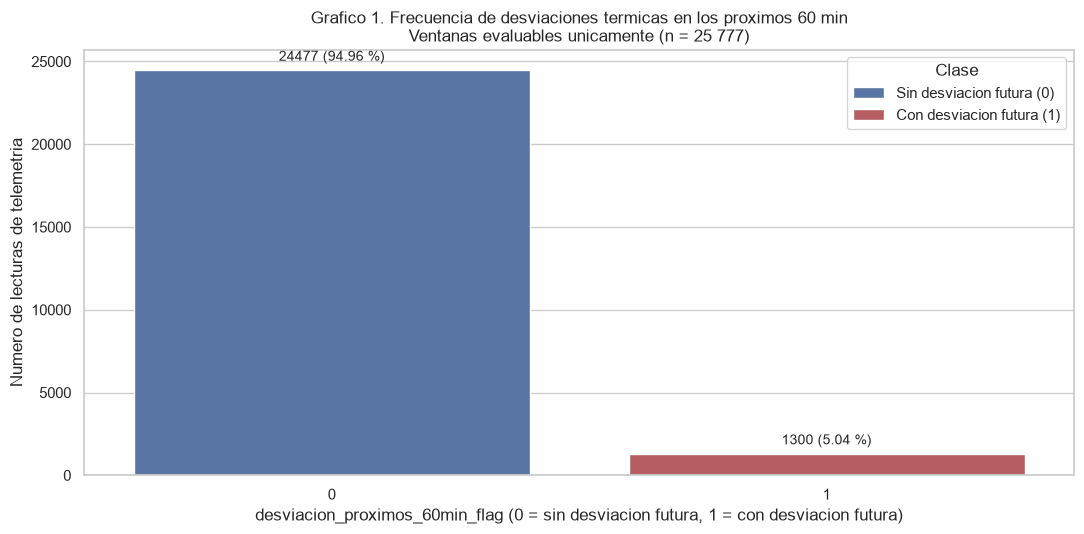

GRAFICO 1 - LECTURA
  Filas usadas: 25777 de 28448 (se excluyen 2671 ventanas no evaluables)
  Hecho observado: clase 0 = 24477 lecturas (94.96 %), clase 1 = 1300 lecturas (5.04 %)
  Hecho observado: la clase positiva es la minoritaria, con prevalencia 0.050433
  Posible interpretacion: la proporcion de ventanas con desviacion posterior es baja,
  lo que hace que el desbalance sea el rasgo dominante de la variable objetivo.
  Limitacion: el conteo por lectura no equivale al conteo por viaje; los viajes
  aportan entre 0 y 10 ventanas positivas, y 862 de 1200 viajes no aportan ninguna ventana positiva.


In [21]:
# --- Grafico 1: countplot del objetivo sobre ventanas evaluables.
fig, ax = plt.subplots(figsize=VIS['figsize'])
sns.countplot(data=analitico, x=objetivo, hue=objetivo, palette=VIS['paleta'],
              order=[0, 1], legend=False, ax=ax)
for indice, clase in enumerate([0, 1]):
    cantidad = int((analitico[objetivo] == clase).sum())
    porcentaje = cantidad / len(analitico) * 100
    ax.text(indice, cantidad + len(analitico) * 0.015,
            f'{cantidad} ({porcentaje:.2f} %)', ha='center', va='bottom', fontsize=10)
ax.set_title('Grafico 1. Frecuencia de desviaciones termicas en los proximos 60 min\n'
             f'Ventanas evaluables unicamente (n = {len(analitico):,})'.replace(',', ' '),
             fontsize=12)
ax.set_xlabel('desviacion_proximos_60min_flag (0 = sin desviacion futura, 1 = con desviacion futura)')
ax.set_ylabel('Numero de lecturas de telemetria')
ax.legend(title='Clase', labels=['Sin desviacion futura (0)', 'Con desviacion futura (1)'],
          loc='upper right')
fig.tight_layout()
plt.show()

conteo = analitico[objetivo].value_counts().sort_index()
print('GRAFICO 1 - LECTURA')
print('  Filas usadas:', len(analitico), 'de', len(gold),
      f'(se excluyen {len(excluidas)} ventanas no evaluables)')
print(f"  Hecho observado: clase 0 = {int(conteo[0])} lecturas "
      f"({float(conteo[0]) / len(analitico) * 100:.2f} %), clase 1 = {int(conteo[1])} lecturas "
      f"({float(conteo[1]) / len(analitico) * 100:.2f} %)")
print('  Hecho observado: la clase positiva es la minoritaria, con prevalencia',
      round(float(conteo[1]) / len(analitico), 6))
print('  Posible interpretacion: la proporcion de ventanas con desviacion posterior es baja,')
print('  lo que hace que el desbalance sea el rasgo dominante de la variable objetivo.')
print('  Limitacion: el conteo por lectura no equivale al conteo por viaje; los viajes')
print('  aportan entre', int(resumen_viaje['ventanas_positivas'].min()), 'y',
      int(resumen_viaje['ventanas_positivas'].max()), 'ventanas positivas, y',
      int((resumen_viaje['ventanas_positivas'] == 0).sum()), 'de', len(resumen_viaje),
      'viajes no aportan ninguna ventana positiva.')

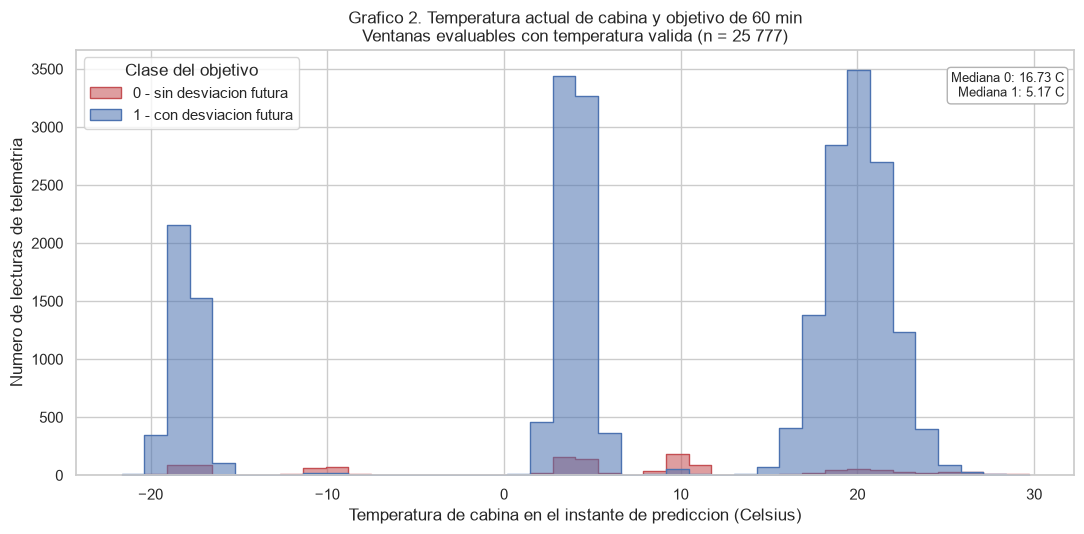

GRAFICO 2 - LECTURA
  Filas usadas: 25777 | excluidas por temperatura nula: 0
  Hecho observado: regimenes de temperatura ocupados en la poblacion analitica: 3 de 3 posibles
  Lecturas por regimen y clase del objetivo:


banda_temperatura,congelado (<-10 C),templado (-10 a 10 C),calido (>10 C)
desviacion_proximos_60min_flag,,,
0,4174,7598,12705
1,274,556,470


  Hecho observado: regimenes presentes en cada clase (0, 1): {0: 3, 1: 3}
  Hecho observado: ambas clases tienen lecturas en todos los regimenes: True
  Hecho observado: rangos por clase, clase 0 [-21.63, 29.44] C y clase 1 [-19.62, 29.69] C => solapamiento de 49.06 C
  Hecho observado: medianas por clase: {0: 16.73, 1: 5.17}
  Posible interpretacion: la diferencia entre medianas se ajusta a la mezcla de regimenes,
  no a un efecto aislado de la temperatura; la temperatura sola no separa las clases.
  Limitacion: el grafico no mide capacidad predictiva; producto_id no es un predictor
  minimo y no se usa como variable de entrada en el modelo obligatorio.


In [22]:
# --- Grafico 2: histplot de temperatura actual con hue del objetivo.
datos_g2 = analitico.loc[analitico[COL['temp_actual']].notna(),
                         [COL['temp_actual'], objetivo]].copy()
datos_g2[objetivo] = datos_g2[objetivo].astype(int)
datos_g2['Clase'] = datos_g2[objetivo].map({0: '0 - sin desviacion futura', 1: '1 - con desviacion futura'})

fig, ax = plt.subplots(figsize=VIS['figsize'])
sns.histplot(data=datos_g2, x=COL['temp_actual'], hue='Clase', bins=VIS['bins_hist'],
             element='step', stat='count', common_norm=False, palette=VIS['paleta_etiquetas'],
             alpha=0.55, ax=ax)
ax.set_title('Grafico 2. Temperatura actual de cabina y objetivo de 60 min\n'
             f'Ventanas evaluables con temperatura valida (n = {len(datos_g2):,})'.replace(',', ' '),
             fontsize=12)
ax.set_xlabel('Temperatura de cabina en el instante de prediccion (Celsius)')
ax.set_ylabel('Numero de lecturas de telemetria')
ax.legend(title='Clase del objetivo', labels=['0 - sin desviacion futura',
                                              '1 - con desviacion futura'], loc='upper left')
ax.text(0.99, 0.95,
        f"Mediana 0: {datos_g2.loc[datos_g2[objetivo] == 0, COL['temp_actual']].median():.2f} C"
        f"\nMediana 1: {datos_g2.loc[datos_g2[objetivo] == 1, COL['temp_actual']].median():.2f} C",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.7'))
fig.tight_layout()
plt.show()

medianas = analitico.groupby(objetivo)[COL['temp_actual']].median().round(4)
banda_clase = analitico.groupby([objetivo, 'banda_temperatura'], observed=True).size().unstack()
banda_clase = banda_clase.reindex(columns=CONFIG['etiquetas_banda'], fill_value=0)
regimenes_por_clase = (banda_clase > 0).sum(axis=1)
regimenes_ocupados = int((banda_clase.sum(axis=0) > 0).sum())
ambas_clases_en_todos = bool((banda_clase > 0).all().all())
rango_por_clase = analitico.groupby(objetivo)[COL['temp_actual']].agg(['min', 'max']).round(2)
solapamiento_rangos = float(min(rango_por_clase.loc[0, 'max'], rango_por_clase.loc[1, 'max'])
                            - max(rango_por_clase.loc[0, 'min'], rango_por_clase.loc[1, 'min']))

print('GRAFICO 2 - LECTURA')
print('  Filas usadas:', len(datos_g2), '| excluidas por temperatura nula:',
      int(analitico[COL['temp_actual']].isna().sum()))
print('  Hecho observado: regimenes de temperatura ocupados en la poblacion analitica:',
      regimenes_ocupados, 'de', len(CONFIG['etiquetas_banda']), 'posibles')
print('  Lecturas por regimen y clase del objetivo:')
display(banda_clase)
print('  Hecho observado: regimenes presentes en cada clase (0, 1):',
      regimenes_por_clase.to_dict())
print('  Hecho observado: ambas clases tienen lecturas en todos los regimenes:',
      ambas_clases_en_todos)
print('  Hecho observado: rangos por clase, clase 0',
      f"[{rango_por_clase.loc[0, 'min']}, {rango_por_clase.loc[0, 'max']}] C",
      'y clase 1', f"[{rango_por_clase.loc[1, 'min']}, {rango_por_clase.loc[1, 'max']}] C",
      '=> solapamiento de', round(solapamiento_rangos, 2), 'C')
print('  Hecho observado: medianas por clase:', medianas.to_dict())
print('  Posible interpretacion: la diferencia entre medianas se ajusta a la mezcla de regimenes,')
print('  no a un efecto aislado de la temperatura; la temperatura sola no separa las clases.')
print('  Limitacion: el grafico no mide capacidad predictiva; producto_id no es un predictor')
print('  minimo y no se usa como variable de entrada en el modelo obligatorio.')

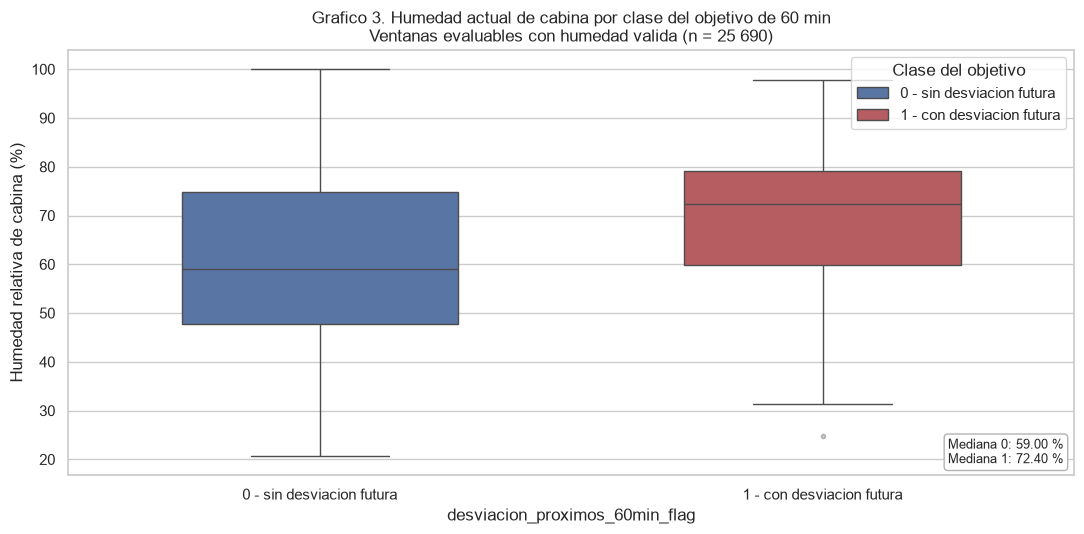

GRAFICO 3 - LECTURA
  Filas usadas: 25690 | excluidas solo del eje por humedad nula: 87 (nunca se imputan)
  Hecho observado: cuartiles por clase


,p25,p50,p75
clase_objetivo,,,
0,47.80,59.0,74.8
1,59.85,72.4,79.2


  Hecho observado: amplitud del intervalo intercuartil de la clase 0: 27.0 puntos
  Hecho observado: amplitud del intervalo intercuartil de la clase 1: 19.35 puntos
  Hecho observado: el borde superior del IQR de la clase 0 es 74.80 % y el inferior de la clase 1 es 59.85 % => solapamiento de 14.95 puntos porcentuales
  Posible interpretacion: la humedad de la clase 1 esta desplazada hacia valores mas altos,
  pero las cajas se solapan de forma amplia: la humedad por si sola no distingue las clases.
  Limitacion: los puntos atipicos mostrados se conservan; el grafico no propone recorte.


In [23]:
# --- Grafico 3: boxplot de humedad actual por clase del objetivo.
datos_g3 = analitico.loc[analitico[COL['humedad_actual']].notna(),
                         [COL['humedad_actual'], objetivo]].copy()
datos_g3[objetivo] = datos_g3[objetivo].astype(int)
datos_g3['Clase'] = datos_g3[objetivo].map({0: '0 - sin desviacion futura', 1: '1 - con desviacion futura'})

fig, ax = plt.subplots(figsize=VIS['figsize'])
sns.boxplot(data=datos_g3, x='Clase', y=COL['humedad_actual'], hue='Clase',
            palette=VIS['paleta_etiquetas'], legend=False, width=0.55,
            flierprops=dict(marker='o', markersize=3, alpha=0.35, markerfacecolor='0.4'),
            ax=ax)
ax.set_title('Grafico 3. Humedad actual de cabina por clase del objetivo de 60 min\n'
             f'Ventanas evaluables con humedad valida (n = {len(datos_g3):,})'.replace(',', ' '),
             fontsize=12)
ax.set_xlabel('desviacion_proximos_60min_flag')
ax.set_ylabel('Humedad relativa de cabina (%)')
ax.legend(title='Clase del objetivo', labels=['0 - sin desviacion futura', '1 - con desviacion futura'],
          loc='upper right')
medianas_h = analitico.groupby(objetivo)[COL['humedad_actual']].median().round(3)
ax.text(0.99, 0.02, 'Mediana 0: ' + f"{medianas_h[0]:.2f} %" + '\nMediana 1: ' + f"{medianas_h[1]:.2f} %",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.7'))
fig.tight_layout()
plt.show()

cuartiles = analitico.groupby(objetivo)[COL['humedad_actual']].quantile([0.25, 0.5, 0.75]).unstack().round(3)
cuartiles.columns = ['p25', 'p50', 'p75']
cuartiles.index.name = 'clase_objetivo'
solapamiento = float(min(cuartiles.loc[0, 'p75'], cuartiles.loc[1, 'p75'])
                      - max(cuartiles.loc[0, 'p25'], cuartiles.loc[1, 'p25']))
print('GRAFICO 3 - LECTURA')
print('  Filas usadas:', len(datos_g3), '| excluidas solo del eje por humedad nula:',
      int(analitico[COL['humedad_actual']].isna().sum()), '(nunca se imputan)')
print('  Hecho observado: cuartiles por clase')
display(cuartiles)
print('  Hecho observado: amplitud del intervalo intercuartil de la clase 0:',
      round(float(cuartiles.loc[0, 'p75'] - cuartiles.loc[0, 'p25']), 3), 'puntos')
print('  Hecho observado: amplitud del intervalo intercuartil de la clase 1:',
      round(float(cuartiles.loc[1, 'p75'] - cuartiles.loc[1, 'p25']), 3), 'puntos')
print('  Hecho observado: el borde superior del IQR de la clase 0 es',
      f"{cuartiles.loc[0, 'p75']:.2f} %", 'y el inferior de la clase 1 es',
      f"{cuartiles.loc[1, 'p25']:.2f} %", '=> solapamiento de', round(solapamiento, 3),
      'puntos porcentuales')
print('  Posible interpretacion: la humedad de la clase 1 esta desplazada hacia valores mas altos,')
print('  pero las cajas se solapan de forma amplia: la humedad por si sola no distingue las clases.')
print('  Limitacion: los puntos atipicos mostrados se conservan; el grafico no propone recorte.')

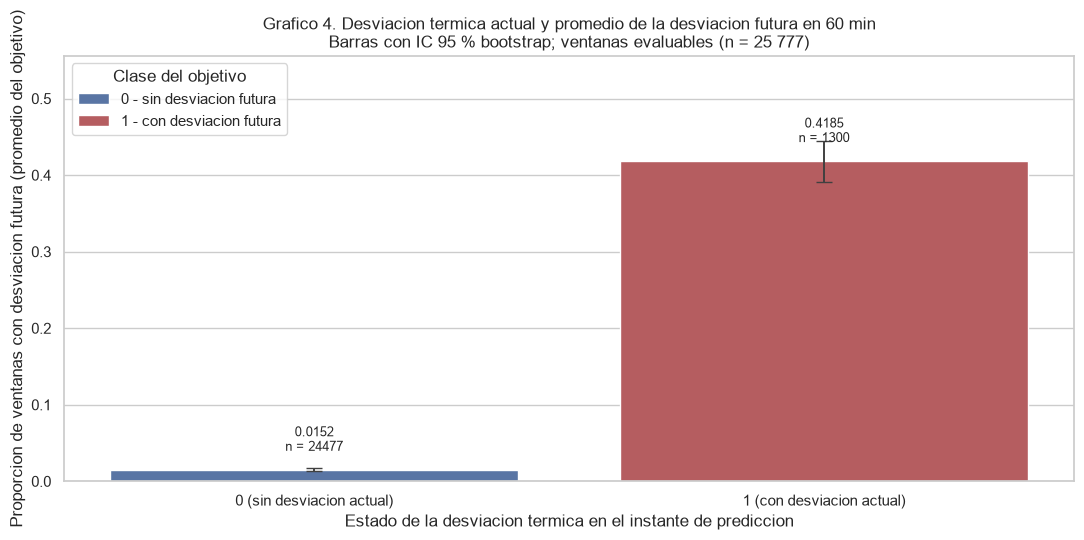

GRAFICO 4 - LECTURA


,desviacion_termica_flag,lecturas,promedio_objetivo,ic_inferior,ic_superior
0,0 (sin desviacion actual),24477,0.015157,0.013605,0.016750
1,1 (con desviacion actual),1300,0.418462,0.390769,0.444615


  Hecho observado: con desviacion actual, el promedio del objetivo es 0.4185 frente a 0.0152 sin desviacion actual; razon 27.61
  Hecho observado: IC sin desviacion actual [0.013605, 0.016750] e IC con desviacion actual [0.390769, 0.444615]
  Hecho observado: los intervalos de bootstrap no se solapan: True (ic inferior con desviacion 0.390769 > ic superior sin desviacion 0.01675 )
  Posible interpretacion: la desviacion ya presente en el instante t se asocia con una
  mayor proporcion de desviaciones dentro de la siguiente hora. La etiqueta se define con
  la ventana (t, t+60] estricta, de modo que la desviacion del instante t no se cuenta como
  evento futuro, pero su presencia indica un estado termico ya alterado.
  Limitacion: la barra es la media de un indicador 0/1; describe ventanas, no viajes,
  no mide riesgo individual y no permite afirmar que la desviacion actual produce la futura.


In [24]:
# --- Grafico 4: desviacion termica actual frente al promedio del objetivo futuro.
def _ic_boot(serie, rng, n_boot, nivel):
    valores = serie.to_numpy(dtype=float)
    n = len(valores)
    indices = rng.integers(0, n, size=(n_boot, n))
    medias = valores[indices].mean(axis=1)
    alpha = (1 - nivel) / 2
    return float(np.quantile(medias, alpha)), float(np.quantile(medias, 1 - alpha))


resumen_g4 = []
for clase in [0, 1]:
    serie = analitico.loc[analitico[objetivo] == clase, COL['flag_actual']]
    bajo, alto = _ic_boot(serie, rng, CONFIG['bootstrap']['n_resampleos'],
                          CONFIG['bootstrap']['nivel'])
    resumen_g4.append({
        'desviacion_termica_flag': f'{clase} (sin desviacion actual)' if clase == 0
                                  else f'{clase} (con desviacion actual)',
        'lecturas': int(serie.size),
        'promedio_objetivo': round(float(serie.mean()), 6),
        'ic_inferior': round(bajo, 6),
        'ic_superior': round(alto, 6),
    })
resumen_g4 = pd.DataFrame(resumen_g4)

fig, ax = plt.subplots(figsize=VIS['figsize'])
sns.barplot(data=resumen_g4, x='desviacion_termica_flag', y='promedio_objetivo',
            hue='desviacion_termica_flag', palette=VIS['paleta_g4'],
            legend=False, errorbar=None, ax=ax)
ax.errorbar(x=range(len(resumen_g4)),
            y=resumen_g4['promedio_objetivo'],
            yerr=[resumen_g4['promedio_objetivo'] - resumen_g4['ic_inferior'],
                  resumen_g4['ic_superior'] - resumen_g4['promedio_objetivo']],
            fmt='none', ecolor='0.25', capsize=6, linewidth=1.4)
for indice, fila in enumerate(resumen_g4.itertuples()):
    ax.text(indice, fila.promedio_objetivo + 0.02,
            f'{fila.promedio_objetivo:.4f}\nn = {fila.lecturas}',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, float(resumen_g4['ic_superior'].max()) * 1.25)
ax.set_title('Grafico 4. Desviacion termica actual y promedio de la desviacion futura en 60 min\n'
             f'Barras con IC {int(CONFIG["bootstrap"]["nivel"] * 100)} % bootstrap; ventanas evaluables '
             f'(n = {len(analitico):,})'.replace(',', ' '), fontsize=12)
ax.set_xlabel('Estado de la desviacion termica en el instante de prediccion')
ax.set_ylabel('Proporcion de ventanas con desviacion futura (promedio del objetivo)')
ax.legend(title='Clase del objetivo', labels=['0 - sin desviacion futura', '1 - con desviacion futura'],
          loc='upper left')
fig.tight_layout()
plt.show()

razon_g4 = float(resumen_g4['promedio_objetivo'][1] / resumen_g4['promedio_objetivo'][0])
ic_sin_desviacion = (float(resumen_g4['ic_inferior'][0]), float(resumen_g4['ic_superior'][0]))
ic_con_desviacion = (float(resumen_g4['ic_inferior'][1]), float(resumen_g4['ic_superior'][1]))
ic_separados = bool(ic_con_desviacion[0] > ic_sin_desviacion[1])
print('GRAFICO 4 - LECTURA')
display(resumen_g4)
print('  Hecho observado: con desviacion actual, el promedio del objetivo es',
      f"{resumen_g4['promedio_objetivo'][1]:.4f}", 'frente a',
      f"{resumen_g4['promedio_objetivo'][0]:.4f}", 'sin desviacion actual; razon',
      round(razon_g4, 2))
print('  Hecho observado: IC sin desviacion actual',
      f'[{ic_sin_desviacion[0]:.6f}, {ic_sin_desviacion[1]:.6f}]',
      'e IC con desviacion actual',
      f'[{ic_con_desviacion[0]:.6f}, {ic_con_desviacion[1]:.6f}]')
print('  Hecho observado: los intervalos de bootstrap no se solapan:', ic_separados,
      '(ic inferior con desviacion', round(ic_con_desviacion[0], 6),
      '> ic superior sin desviacion', round(ic_sin_desviacion[1], 6), ')')
print('  Posible interpretacion: la desviacion ya presente en el instante t se asocia con una')
print('  mayor proporcion de desviaciones dentro de la siguiente hora. La etiqueta se define con')
print('  la ventana (t, t+60] estricta, de modo que la desviacion del instante t no se cuenta como')
print('  evento futuro, pero su presencia indica un estado termico ya alterado.')
print('  Limitacion: la barra es la media de un indicador 0/1; describe ventanas, no viajes,')
print('  no mide riesgo individual y no permite afirmar que la desviacion actual produce la futura.')

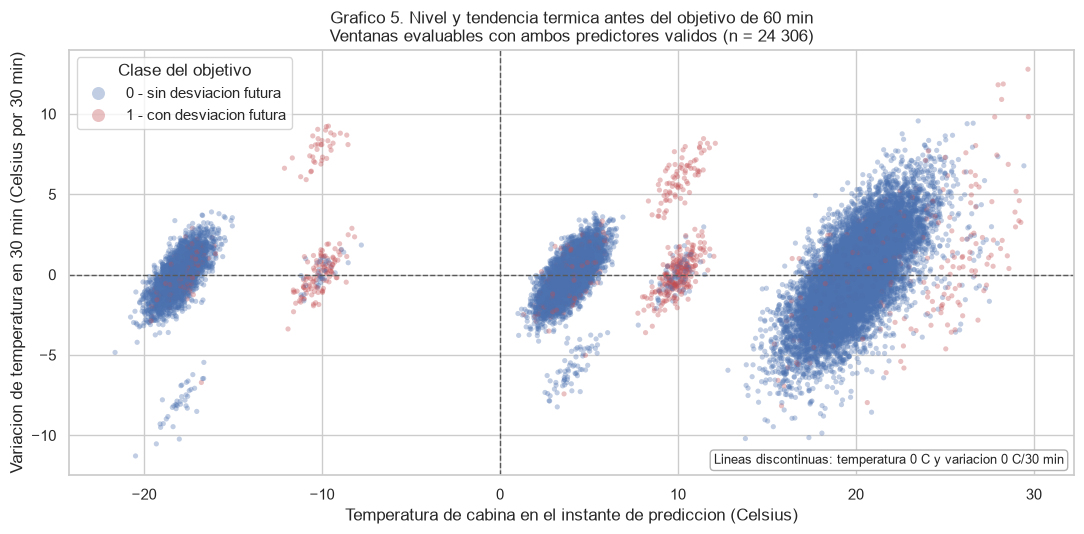

GRAFICO 5 - LECTURA
  Filas usadas: 24306 | excluidas solo del eje por predictor derivado nulo: 1471
  Hecho observado: cuartiles de la variacion de 30 min por clase


,p25,p50,p75
clase_objetivo,,,
0,-1.16,-0.03,1.11
1,-0.76,0.22,1.39


  Hecho observado: solapamiento de los intervalos intercuartiles en 1.87 Celsius; el grafico muestra una nube continua donde las clases se superponen
  Hecho observado: el numero de puntos con variacion absoluta mayor que 5.0 C es 825
  Posible interpretacion: la clase 1 se concentra en variaciones positivas mientras la
  clase 0 se centra cerca de cero, es decir la pendiente reciente acompaÃ±a la asociacion,
  pero el solapamiento es amplio y la nube no permite trazar un limite limpio entre clases.
  Limitacion: el grafico es descriptivo y no estima una frontera de decision; ademas los
  predictores estan correlacionados entre si (ver tabla de correlaciones), por lo que la
  lectura conjunta no puede atribuirse a una sola variable.


In [25]:
# --- Grafico 5: scatterplot temperatura actual frente a variacion de 30 minutos.
datos_g5 = analitico.loc[analitico[[COL['temp_actual'], COL['var_30min']]].notna().all(axis=1),
                         [COL['temp_actual'], COL['var_30min'], objetivo]].copy()
datos_g5[objetivo] = datos_g5[objetivo].astype(int)
datos_g5['Clase'] = datos_g5[objetivo].map({0: '0 - sin desviacion futura', 1: '1 - con desviacion futura'})

fig, ax = plt.subplots(figsize=VIS['figsize'])
sns.scatterplot(data=datos_g5, x=COL['temp_actual'], y=COL['var_30min'], hue='Clase',
                palette=VIS['paleta_etiquetas'], alpha=VIS['alpha_scatter'],
                s=VIS['s_scatter'], linewidths=0, ax=ax)
ax.axhline(0, color='0.35', linestyle='--', linewidth=1)
ax.axvline(0, color='0.35', linestyle='--', linewidth=1)
ax.set_title('Grafico 5. Nivel y tendencia termica antes del objetivo de 60 min\n'
             f'Ventanas evaluables con ambos predictores validos (n = {len(datos_g5):,})'.replace(',', ' '),
             fontsize=12)
ax.set_xlabel('Temperatura de cabina en el instante de prediccion (Celsius)')
ax.set_ylabel('Variacion de temperatura en 30 min (Celsius por 30 min)')
ax.legend(title='Clase del objetivo', markerscale=2.5, loc='upper left')
ax.text(0.99, 0.02,
        'Lineas discontinuas: temperatura 0 C y variacion 0 C/30 min',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.7'))
fig.tight_layout()
plt.show()

cuartiles_var = analitico.groupby(objetivo)[COL['var_30min']].quantile(
    [0.25, 0.5, 0.75]).unstack().round(3)
cuartiles_var.columns = ['p25', 'p50', 'p75']
cuartiles_var.index.name = 'clase_objetivo'
solape_var = float(min(cuartiles_var.loc[0, 'p75'], cuartiles_var.loc[1, 'p75'])
                   - max(cuartiles_var.loc[0, 'p25'], cuartiles_var.loc[1, 'p25']))
print('GRAFICO 5 - LECTURA')
print('  Filas usadas:', len(datos_g5), '| excluidas solo del eje por predictor derivado nulo:',
      int(analitico[COL['var_30min']].isna().sum()))
print('  Hecho observado: cuartiles de la variacion de 30 min por clase')
display(cuartiles_var)
print('  Hecho observado: solapamiento de los intervalos intercuartiles en', round(solape_var, 3),
      'Celsius; el grafico muestra una nube continua donde las clases se superponen')
print('  Hecho observado: el numero de puntos con variacion absoluta mayor que',
      CONFIG['umbral_extremo_var'], 'C es',
      int(datos_g5[COL['var_30min']].abs().gt(CONFIG['umbral_extremo_var']).sum()))
print('  Posible interpretacion: la clase 1 se concentra en variaciones positivas mientras la')
print('  clase 0 se centra cerca de cero, es decir la pendiente reciente acompaÃ±a la asociacion,')
print('  pero el solapamiento es amplio y la nube no permite trazar un limite limpio entre clases.')
print('  Limitacion: el grafico es descriptivo y no estima una frontera de decision; ademas los')
print('  predictores estan correlacionados entre si (ver tabla de correlaciones), por lo que la')
print('  lectura conjunta no puede atribuirse a una sola variable.')

### Grafico temporal opcional

La seleccion de viajes es reproducible y no manual: se ordenan por numero de ventanas
positivas y, en empate, por identificador de viaje. Como se seleccionan precisamente los
viajes que tienen el caso, el resultado es ilustrativo y no generalizable.

GRAFICO 6 - SELECCION REPRODUCIBLE DE VIAJES
  Criterio: ventana positiva mas alta, luego mas lecturas, luego viaje mas pequeno.
  Viajes candidatos con al menos 15 lecturas evaluables y alguna ventana positiva: 338
  Viajes graficados: ['VIA-00087', 'VIA-00593', 'VIA-00792']
  Ventanas positivas por viaje graficado: [10, 10, 9]
  Advertencia de sesgo: son justamente los viajes con casos positivos, no una muestra aleatoria.
  La columna auxiliar tiene_ventana_positiva se deriva del objetivo y existe solo para
  marcar visualmente la serie: no es admisible como variable de entrada del modelo.


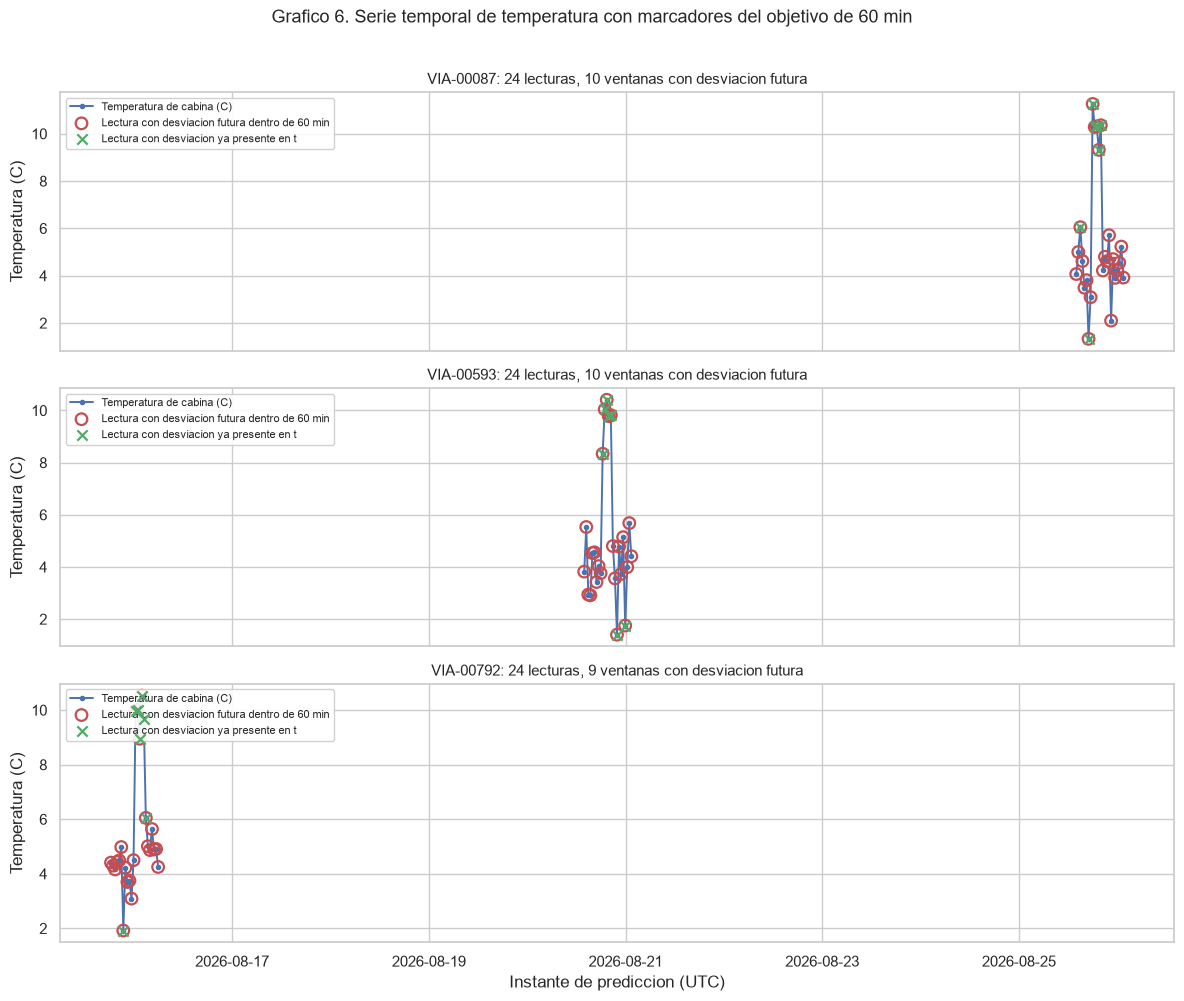

GRAFICO 6 - LECTURA
  VIA-00087: lecturas 24, ventanas positivas 10,
     temperatura min 1.33 C, max 11.26 C, mediana 4.62 C, lecturas con desviacion actual 7
  VIA-00593: lecturas 24, ventanas positivas 10,
     temperatura min 1.40 C, max 10.41 C, mediana 4.47 C, lecturas con desviacion actual 7
  VIA-00792: lecturas 24, ventanas positivas 9,
     temperatura min 1.92 C, max 10.53 C, mediana 4.69 C, lecturas con desviacion actual 7
  Hecho observado: los marcadores rojos pueden aparecer antes, despues o al mismo tiempo
  que las desviaciones ya presentes (marcas verdes); el objetivo es una ventana futura
  (t, t+60], no un evento en el instante marcado.
  Posible interpretacion: en algunos viajes las ventanas positivas se concentran en
  tramos con temperatura baja o con cambios pronunciados, lo que es coherente con lo
  visto en los graficos 2, 4 y 5.
  Limitacion: 3 viajes elegidos por tener el caso, sin generalizacion estadistica;
  la cadencia no es regular y puede faltar alguna

In [26]:
# --- Grafico temporal opcional: temperatura por viaje con marcadores de objetivo positivo.
candidatos = (analitico.groupby(entidad)[objetivo]
              .agg(ventanas_positivas='sum', lecturas='size')
              .query('ventanas_positivas > 0 and lecturas >= @CONFIG["min_lecturas_lineplot"]')
              .reset_index()
              .sort_values(['ventanas_positivas', 'lecturas', entidad], ascending=[False, False, True]))
viajes_g6 = candidatos.head(CONFIG['viajes_lineplot'])[entidad].tolist()

print('GRAFICO 6 - SELECCION REPRODUCIBLE DE VIAJES')
print('  Criterio: ventana positiva mas alta, luego mas lecturas, luego viaje mas pequeno.')
print('  Viajes candidatos con al menos', CONFIG['min_lecturas_lineplot'],
      'lecturas evaluables y alguna ventana positiva:', len(candidatos))
print('  Viajes graficados:', viajes_g6)
print('  Ventanas positivas por viaje graficado:',
      candidatos.head(CONFIG['viajes_lineplot'])[ 'ventanas_positivas'].tolist())
print('  Advertencia de sesgo: son justamente los viajes con casos positivos, no una muestra aleatoria.')
print('  La columna auxiliar tiene_ventana_positiva se deriva del objetivo y existe solo para')
print('  marcar visualmente la serie: no es admisible como variable de entrada del modelo.')

panel = gold.loc[gold[entidad].isin(viajes_g6)].copy()
panel['ts'] = pd.to_datetime(panel[COL['timestamp']], format='ISO8601', utc=True)
panel = panel.sort_values([entidad, 'ts'], kind='stable')
panel['tiene_ventana_positiva'] = panel[entidad].map(
    analitico.groupby(entidad)[objetivo].max()).fillna(0).astype(int) == 1

fig, axes = plt.subplots(len(viajes_g6), 1, figsize=(12, 3.4 * len(viajes_g6)), sharex=True)
axes = np.atleast_1d(axes)
for ax, viaje in zip(axes, viajes_g6):
    tramo = panel.loc[panel[entidad] == viaje]
    ax.plot(tramo['ts'], tramo[COL['temp_actual']], color='#4C72B0', linewidth=1.4,
            marker='o', markersize=3, label='Temperatura de cabina (C)')
    marcados = tramo.loc[tramo['tiene_ventana_positiva']]
    ax.scatter(marcados['ts'], marcados[COL['temp_actual']], s=70, facecolor='none',
               edgecolor='#C44E52', linewidths=1.6, zorder=5,
               label='Lectura con desviacion futura dentro de 60 min')
    desvios = tramo.loc[tramo[COL['flag_actual']] == 1]
    ax.scatter(desvios['ts'], desvios[COL['temp_actual']], marker='x', s=55, color='#55A868',
               linewidths=1.6, zorder=6, label='Lectura con desviacion ya presente en t')
    positivos = int(analitico.loc[analitico[entidad] == viaje, objetivo].sum())
    ax.set_title(f'{viaje}: {len(tramo)} lecturas, {positivos} ventanas con desviacion futura',
                 fontsize=11)
    ax.set_ylabel('Temperatura (C)')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
axes[-1].set_xlabel('Instante de prediccion (UTC)')
fig.suptitle('Grafico 6. Serie temporal de temperatura con marcadores del objetivo de 60 min',
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

print('GRAFICO 6 - LECTURA')
for viaje in viajes_g6:
    tramo = panel.loc[panel[entidad] == viaje]
    positivos_viaje = analitico.loc[analitico[entidad] == viaje, objetivo].sum()
    print(f'  {viaje}: lecturas {len(tramo)}, ventanas positivas {int(positivos_viaje)},')
    print(f'     temperatura min {tramo[COL["temp_actual"]].min():.2f} C, '
          f'max {tramo[COL["temp_actual"]].max():.2f} C, '
          f'mediana {tramo[COL["temp_actual"]].median():.2f} C, '
          f'lecturas con desviacion actual {int(tramo[COL["flag_actual"]].sum())}')
print('  Hecho observado: los marcadores rojos pueden aparecer antes, despues o al mismo tiempo')
print('  que las desviaciones ya presentes (marcas verdes); el objetivo es una ventana futura')
print('  (t, t+60], no un evento en el instante marcado.')
print('  Posible interpretacion: en algunos viajes las ventanas positivas se concentran en')
print('  tramos con temperatura baja o con cambios pronunciados, lo que es coherente con lo')
print('  visto en los graficos 2, 4 y 5.')
print('  Limitacion: 3 viajes elegidos por tener el caso, sin generalizacion estadistica;')
print('  la cadencia no es regular y puede faltar alguna lectura intermedia.')

## 10. Controles finales

Ninguno de estos controles modifica Gold; todos comparan lo leido con lo que el informe
debe declarar.

In [27]:
# --- Controles finales del EDA.
HASH_GOLD_CIERRE = hashlib.sha256(PATHS['gold'].read_bytes()).hexdigest()

controles = []

def registrar(nombre, condicion, detalle=''):
    controles.append({'control': nombre, 'resultado': 'OK' if condicion else 'REVISAR',
                      'detalle': detalle})


registrar('Gold no modificado (SHA-256 identique)', HASH_GOLD_ENTRADA == HASH_GOLD_CIERRE,
          HASH_GOLD_ENTRADA[:16] + '...')
registrar('Forma Gold 28448 x 20',
          gold.shape == (28448, 20), f'{gold.shape[0]} filas x {gold.shape[1]} columnas')
registrar('Clave de lectura unica', not gold.duplicated(clave).any())
registrar('Sin duplicados exactos', int(gold.duplicated().sum()) == 0)
registrar('Faltantes no clasificados en cero',
          (int(inesperados['no_clasificados'].sum()) if len(inesperados) else 0) == 0)
registrar('Objetivo nulo solo en ventanas no evaluables',
          int((gold[objetivo].isna() == (~gold[evaluable])).sum()) == len(gold))
registrar('Poblacion analitica usa solo ventanas evaluables',
          bool(analitico[evaluable].all()) and bool(analitico[objetivo].notna().all()),
          f'{len(analitico)} filas')
registrar('Objetivo contiene solo 0 y 1', clases_presentes == [0, 1], str(clases_presentes))
registrar('Gold conservado: analitico + excluidas = total',
          len(analitico) + len(excluidas) == len(gold))
registrar('Todo nulo de temperatura anterior tiene motivo',
          int((gold[temp_ant].isna() & gold[mot_temp].isna()).sum()) == 0)
registrar('Todo nulo de variacion de 30 min tiene motivo',
          int((gold[var_30].isna() & gold[mot_var].isna()).sum()) == 0)
registrar('Motivos de la variacion cubren todos sus nulos',
          int(gold[var_30].isna().sum()) == int((primera_lectura | sin_historia).sum()))
registrar('Sin antecedentes posteriores al instante de prediccion',
          violan_temp == 0 and violan_var == 0)
registrar('Predictores minimos disjuntos de columnas no admisibles',
          len(set(PRED) & set(CONFIG['columnas_no_admisibles_como_entrada'])) == 0)
registrar('Sin centinelas en temperatura ni variacion',
          int(gold[COL['temp_actual']].eq(CONFIG['centinela']).sum()) == 0
          and int(gold[COL['var_30min']].eq(CONFIG['centinela']).sum()) == 0)
registrar('Humedad dentro de 0 a 100',
          int((gold[COL['humedad_actual']].notna()
               & ~gold[COL['humedad_actual']].between(*CONFIG['humedad_rango_valido'])).sum()) == 0)
registrar('Timestamps parseados sin errores', int(ts.isna().sum()) == 0)
registrar('No se generaron variables de modelo ni se entreno ningun modelo', True,
          'el EDA no contiene ajustes ni entrenamiento')

controles = pd.DataFrame(controles)
print('CONTROLES FINALES DEL EDA')
display(controles)
print('  Controles en OK:', int((controles['resultado'] == 'OK').sum()),
      'de', len(controles))
fallos = controles.loc[controles['resultado'] != 'OK', 'control'].tolist()
print('  Controles a revisar:', fallos if fallos else 'ninguno')
assert not fallos, f'Controles con resultado REVISAR: {fallos}'
print()
print('  No se imputo ningun valor, no se elimino ninguna fila y no se escribio ningun archivo')
print('  de datos. El unico archivo generado por esta etapa es el informe MD, redactado')
print('  despues de esta ejecucion con estas cifras.')

CONTROLES FINALES DEL EDA


,control,resultado,detalle
0,Gold no modificado (SHA-256 identique),OK,f0194aae8dfe9073...
1,Forma Gold 28448 x 20,OK,28448 filas x 20 columnas
2,Clave de lectura unica,OK,
3,Sin duplicados exactos,OK,
4,Faltantes no clasificados en cero,OK,
5,Objetivo nulo solo en ventanas no evaluables,OK,
6,Poblacion analitica usa solo ventanas evaluables,OK,25777 filas
7,Objetivo contiene solo 0 y 1,OK,"[0, 1]"
8,Gold conservado: analitico + excluidas = total,OK,
9,Todo nulo de temperatura anterior tiene motivo,OK,


  Controles en OK: 18 de 18
  Controles a revisar: ninguno

  No se imputo ningun valor, no se elimino ninguna fila y no se escribio ningun archivo
  de datos. El unico archivo generado por esta etapa es el informe MD, redactado
  despues de esta ejecucion con estas cifras.


In [28]:
# --- Reproducibilidad: versiones, rutas, semilla y reejecucion.
print('REPRODUCIBILIDAD')
print('  Ejecucion UTC:', datetime.now(timezone.utc).isoformat())
print('  Python:', platform.python_version())
print('  pandas:', pd.__version__)
print('  numpy:', np.__version__)
print('  seaborn:', sns.__version__)
print('  matplotlib:', matplotlib.__version__)
print('  Semilla usada:', SEMILLA, '(bootstrap del grafico 4 y seleccion reproducible de viajes)')
print('  Resampleos bootstrap:', CONFIG['bootstrap']['n_resampleos'],
      '| nivel del IC:', CONFIG['bootstrap']['nivel'])
print('  Ruta de deteccion de raiz: ANDINALOG_ROOT o ancestros del directorio actual')
print('  El notebook se ejecuta de arriba abajo, celda por celda, sin estado oculto.')
print('  Dependencias de ejecucion: pandas, numpy, matplotlib y seaborn. En un entorno')
print('  limpio se instalan con: pip install matplotlib seaborn')
print('  Este notebook no escribe archivos: no hay to_csv ni to_parquet.')
print()
print('  Rutas de los entregables:')
print('   ', CONFIG['rutas']['notebook'])
print('   ', CONFIG['rutas']['informe'])
print('  Hash del Gold leido:', HASH_GOLD_CIERRE)
print()
print('  POBLACION ANALIZADA (para el informe)')
print('   Filas Gold:', len(gold), '| columnas:', gold.shape[1])
print('   Viajes:', int(gold[entidad].nunique()), '| ordenes:', int(gold[orden].nunique()))
print('   Ventanas evaluables usadas para el objetivo:', len(analitico))
print('   Ventanas no evaluables excluidas del objetivo:', len(excluidas))
print('   Clase 0:', int(conteo_clase[0]), '| clase 1:', int(conteo_clase[1]),
      '| prevalencia:', round(prevalencia, 6))
print('   Razon mayoria/minoria:', round(razon, 4))
print('   Viajes con al menos una ventana positiva:', viajes_con_positivo, 'de', viajes_cualquier)
print('   Graficos generados: 5 obligatorios + 1 temporal opcional')

REPRODUCIBILIDAD
  Ejecucion UTC: 2026-09-25T19:28:43.693219+00:00
  Python: 3.14.6
  pandas: 3.0.5
  numpy: 2.5.3
  seaborn: 0.13.2
  matplotlib: 3.11.2
  Semilla usada: 20260925 (bootstrap del grafico 4 y seleccion reproducible de viajes)
  Resampleos bootstrap: 2000 | nivel del IC: 0.95
  Ruta de deteccion de raiz: ANDINALOG_ROOT o ancestros del directorio actual
  El notebook se ejecuta de arriba abajo, celda por celda, sin estado oculto.
  Dependencias de ejecucion: pandas, numpy, matplotlib y seaborn. En un entorno
  limpio se instalan con: pip install matplotlib seaborn
  Este notebook no escribe archivos: no hay to_csv ni to_parquet.

  Rutas de los entregables:
    notebooks/eda/EDA_01_AndinaLog_IoT_Gold.ipynb
    informes/eda/Informe_EDA_01_AndinaLog_IoT_Gold.md
  Hash del Gold leido: f0194aae8dfe9073fd0e5bbf14cb72353a02863915e483ceec66027e81406479

  POBLACION ANALIZADA (para el informe)
   Filas Gold: 28448 | columnas: 20
   Viajes: 1200 | ordenes: 1200
   Ventanas evaluabl